# Metaheuristic Hyperparameter Optimization — WaO, RSO, and CSO

## Introduction
This notebook is applying three metaheuristic optimization algorithms to tune the best stacking ensemble for each model set. The aim is to move beyond fixed hyperparameter choices and search for better settings that can improve AUC, recall, and overall screening quality.

This notebook is the main academic contribution of the modelling phase. Standard tuning methods such as grid search and random search are useful, but they either search too slowly or search without learning from earlier results. Metaheuristic optimization is taking a different route. It is using nature-inspired search rules that explore widely at first and then focus more tightly on the best regions of the search space.

A hyperparameter is a setting chosen before a model is trained. Examples include the number of trees, tree depth, or learning rate. These choices can strongly affect how well the final model separates PCOS-positive and PCOS-negative cases. Hyperparameter optimization is the process of finding the best settings for those choices.

In this notebook, Walrus Optimization (WaO), Rat Swarm Optimization (RSO), and Cat Swarm Optimization (CSO) are searching the same hyperparameter space and competing on the same objective: mean 5-fold cross-validated AUC on the training data. Their convergence curves are being compared so we can see not only which optimizer finds the best answer, but also how quickly and how smoothly it gets there.

The current repo results show that the best stacking family for both model sets is `Stack-LR`, so the optimization is currently targeting an LR-meta stack for both Model 1 and Model 2. The notebook still detects the best stacking family from the saved results table at runtime so it remains correct if Notebook 09 is rerun later.

## What This Notebook Produces
This notebook is:
1. explaining the optimization problem in exact mathematical form using LaTeX,
2. implementing WaO, RSO, and CSO from scratch,
3. optimizing the best stacking configuration for both model sets,
4. comparing optimizer convergence and final test performance,
5. selecting one final optimized model for Model 1 and one final optimized model for Model 2,
6. saving the optimized artifacts, convergence arrays, result tables, and theory figures listed below.

## Output Files

| Path | Meaning |
| --- | --- |
| `models/model1_wao_optimized.pkl` | Saved WaO-optimized ensemble artifact for Model 1. |
| `models/model1_rso_optimized.pkl` | Saved RSO-optimized ensemble artifact for Model 1. |
| `models/model1_cso_optimized.pkl` | Saved CSO-optimized ensemble artifact for Model 1. |
| `models/model2_wao_optimized.pkl` | Saved WaO-optimized ensemble artifact for Model 2. |
| `models/model2_rso_optimized.pkl` | Saved RSO-optimized ensemble artifact for Model 2. |
| `models/model2_cso_optimized.pkl` | Saved CSO-optimized ensemble artifact for Model 2. |
| `models/model1_final_optimized.pkl` | Saved the best final optimized Model 1 artifact. |
| `models/model2_final_optimized.pkl` | Saved the best final optimized Model 2 artifact. |
| `models/model1_best_params.json` | Saved the best Model 1 optimizer choice and hyperparameters. |
| `models/model2_best_params.json` | Saved the best Model 2 optimizer choice and hyperparameters. |
| `models/model1_*_convergence.npy` | Saved WaO, RSO, and CSO convergence arrays for Model 1. |
| `models/model2_*_convergence.npy` | Saved WaO, RSO, and CSO convergence arrays for Model 2. |
| `cleaned_data/modelling_sets/optimization_results.csv` | Saved the six optimized-model rows only. |
| `cleaned_data/modelling_sets/final_model_results.csv` | Saved the full final table across individual, stacking, and optimized phases. |
| `images/optimization/01-19_*.png` | Saved the theory diagrams, convergence plots, comparison charts, and final summary figures. |

## Important Note
No new data splitting, scaling, or SMOTE is happening in this notebook. Those steps were locked in Notebook 07. This notebook is only tuning hyperparameters on the saved modelling sets and comparing the optimized results with the already saved individual and stacking baselines.


## Section 1 — Imports and Configuration


In [1]:
# Importing all packages needed for optimization theory, plotting, model building, and result saving.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
import json
import joblib
import time
from copy import deepcopy
from pathlib import Path

from scipy.ndimage import gaussian_filter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

RANDOM_STATE = 42
TARGET = 'pcos_y_n'
N_FOLDS = 5
N_EPOCHS = 10
POP_SIZE = 5
MIN_ITER_BEFORE_STOP = 4
EARLY_STOP_PATIENCE = 3
MIN_DELTA = 0.001
TARGET_GAIN = 0.002

COLORS = {
    'wao': '#1D3557',
    'rso': '#E76F51',
    'cso': '#2A9D8F',
    'baseline': '#888888',
    'best': '#E63946',
    'model1': '#2A9D8F',
    'model2': '#E9C46A',
    'improve': '#40916C',
    'neutral': '#2C3E50'
}


In [3]:
# Resolving the project root is making the notebook work whether it is launched from the repo root or from the notebooks folder.
search_start = Path.cwd().resolve()
candidate_roots = [search_start, *search_start.parents]
PROJECT_ROOT = None
def looks_like_project_root(candidate: Path) -> bool:
    return (
        (candidate / 'cleaned_data').exists() and
        (candidate / 'models').exists() and
        (candidate / 'scripts').exists() and
        (candidate / 'notebooks').exists() and
        (candidate / 'README.md').exists()
    )
for candidate in candidate_roots:
    if looks_like_project_root(candidate):
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing cleaned_data, models, scripts, notebooks, and README.md.')
os.chdir(PROJECT_ROOT)
print(f'Project root resolved to: {PROJECT_ROOT}')

# Creating the output folders is making sure all optimization results have a fixed save location.
os.makedirs('images/optimization', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('cleaned_data/modelling_sets', exist_ok=True)

print('Directory ready: images/optimization')
print('Directory ready: models')
print('Directory ready: cleaned_data/modelling_sets')


Project root resolved to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic
Directory ready: images/optimization
Directory ready: models
Directory ready: cleaned_data/modelling_sets


In [4]:
# Loading the locked modelling data, saved OOF arrays, and previous results is grounding the optimization notebook in the current repo state.
if 'PROJECT_ROOT' not in globals() or not ((Path(PROJECT_ROOT) / 'scripts').exists() and (Path(PROJECT_ROOT) / 'README.md').exists()):
    search_start = Path.cwd().resolve()
    candidate_roots = [search_start, *search_start.parents]
    PROJECT_ROOT = None
    for candidate in candidate_roots:
        if (
            (candidate / 'cleaned_data').exists() and
            (candidate / 'models').exists() and
            (candidate / 'scripts').exists() and
            (candidate / 'notebooks').exists() and
            (candidate / 'README.md').exists()
        ):
            PROJECT_ROOT = candidate
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError('Could not find the project root before loading the modelling files.')
    os.chdir(PROJECT_ROOT)
    print(f'Project root re-resolved to: {PROJECT_ROOT}')

train1 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model1_train.csv')
test1 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model1_test.csv')
train2 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model2_train.csv')
test2 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model2_test.csv')

with open(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'feature_names_model1.json', encoding='utf-8') as f:
    MODEL1_FEATURES = json.load(f)
with open(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'feature_names_model2.json', encoding='utf-8') as f:
    MODEL2_FEATURES = json.load(f)

cv = joblib.load(PROJECT_ROOT / 'models' / 'cv_strategy.pkl')
master_prev = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'master_results_all_models.csv')
oof1 = np.load(PROJECT_ROOT / 'models' / 'model1_oof_predictions.npy')
oof2 = np.load(PROJECT_ROOT / 'models' / 'model2_oof_predictions.npy')

print('Loaded data shapes:')
print(f'train1: {train1.shape}')
print(f'test1 : {test1.shape}')
print(f'train2: {train2.shape}')
print(f'test2 : {test2.shape}')
print()
print(f'Model 1 feature count: {len(MODEL1_FEATURES)}')
print(f'Model 2 feature count: {len(MODEL2_FEATURES)}')
print(f'Model 1 saved OOF shape: {oof1.shape}')
print(f'Model 2 saved OOF shape: {oof2.shape}')
print()
print('Loaded previous master results table:')
print(master_prev.to_string(index=False))


Loaded data shapes:
train1: (582, 20)
test1 : (109, 20)
train2: (582, 16)
test2 : (109, 16)

Model 1 feature count: 19
Model 2 feature count: 15
Model 1 saved OOF shape: (582, 3)
Model 2 saved OOF shape: (582, 3)

Loaded previous master results table:
              model  accuracy  precision  recall     f1    auc model_set algorithm   approach
       Model 1 - LR    0.8349     0.7368  0.7778 0.7568 0.8839   Model 1        LR Individual
       Model 1 - RF    0.8532     0.8125  0.7222 0.7647 0.9098   Model 1        RF Individual
      Model 1 - XGB    0.8716     0.8438  0.7500 0.7941 0.9026   Model 1       XGB Individual
       Model 2 - LR    0.8349     0.7143  0.8333 0.7692 0.8988   Model 2        LR Individual
       Model 2 - RF    0.8349     0.7500  0.7500 0.7500 0.8955   Model 2        RF Individual
      Model 2 - XGB    0.8624     0.8000  0.7778 0.7887 0.9037   Model 2       XGB Individual
 Model 1 - Stack-LR    0.8440     0.7879  0.7222 0.7536 0.9113   Model 1  Stack-LR   Stack

In [5]:
# Separating features and target is preparing the arrays used inside the optimizer objective and the final test evaluation.
X1_train = train1[MODEL1_FEATURES].values
y1_train = train1[TARGET].values
X1_test = test1[MODEL1_FEATURES].values
y1_test = test1[TARGET].values

X2_train = train2[MODEL2_FEATURES].values
y2_train = train2[TARGET].values
X2_test = test2[MODEL2_FEATURES].values
y2_test = test2[TARGET].values

print('Array shapes:')
print(f'X1_train: {X1_train.shape} | y1_train: {y1_train.shape}')
print(f'X1_test : {X1_test.shape} | y1_test : {y1_test.shape}')
print(f'X2_train: {X2_train.shape} | y2_train: {y2_train.shape}')
print(f'X2_test : {X2_test.shape} | y2_test : {y2_test.shape}')
print()
print('Class distribution:')
print('Model 1 train:', pd.Series(y1_train).value_counts().sort_index().to_dict())
print('Model 1 test :', pd.Series(y1_test).value_counts().sort_index().to_dict())
print('Model 2 train:', pd.Series(y2_train).value_counts().sort_index().to_dict())
print('Model 2 test :', pd.Series(y2_test).value_counts().sort_index().to_dict())


Array shapes:
X1_train: (582, 19) | y1_train: (582,)
X1_test : (109, 19) | y1_test : (109,)
X2_train: (582, 15) | y2_train: (582,)
X2_test : (109, 15) | y2_test : (109,)

Class distribution:
Model 1 train: {0: 291, 1: 291}
Model 1 test : {0: 73, 1: 36}
Model 2 train: {0: 291, 1: 291}
Model 2 test : {0: 73, 1: 36}


In [6]:
# Detecting the best stacking family at runtime is keeping this notebook tied to the real Notebook 09 output rather than a hard-coded assumption.
stacking_only = master_prev[master_prev['approach'] == 'Stacking'].copy()
best_stack_rows = (
    stacking_only.sort_values(['model_set', 'auc'], ascending=[True, False])
    .groupby('model_set', as_index=False)
    .first()
)

print('Best stacking rows detected from the saved results:')
print(best_stack_rows.to_string(index=False))

def parse_stack_family(label):
    label = str(label).replace('Stack-', '').strip().upper()
    mapping = {'LR': 'lr', 'RF': 'rf', 'XGB': 'xgb'}
    return mapping[label]

stack_family_m1 = parse_stack_family(
    best_stack_rows.loc[best_stack_rows['model_set'] == 'Model 1', 'algorithm'].iloc[0]
)
stack_family_m2 = parse_stack_family(
    best_stack_rows.loc[best_stack_rows['model_set'] == 'Model 2', 'algorithm'].iloc[0]
)

baseline_individual_m1_auc = master_prev.loc[
    (master_prev['model_set'] == 'Model 1') & (master_prev['approach'] == 'Individual'),
    'auc'
].max()
baseline_stack_m1_auc = master_prev.loc[
    (master_prev['model_set'] == 'Model 1') & (master_prev['approach'] == 'Stacking'),
    'auc'
].max()
baseline_individual_m2_auc = master_prev.loc[
    (master_prev['model_set'] == 'Model 2') & (master_prev['approach'] == 'Individual'),
    'auc'
].max()
baseline_stack_m2_auc = master_prev.loc[
    (master_prev['model_set'] == 'Model 2') & (master_prev['approach'] == 'Stacking'),
    'auc'
].max()

print()
print(f'Model 1 selected stack family: {stack_family_m1}')
print(f'Model 2 selected stack family: {stack_family_m2}')


Best stacking rows detected from the saved results:
model_set              model  accuracy  precision  recall     f1    auc algorithm approach
  Model 1 Model 1 - Stack-LR    0.8440     0.7879  0.7222 0.7536 0.9113  Stack-LR Stacking
  Model 2 Model 2 - Stack-LR    0.8899     0.8529  0.8056 0.8286 0.9037  Stack-LR Stacking

Model 1 selected stack family: lr
Model 2 selected stack family: lr


## Section 2 — Understanding Metaheuristic Optimization

### What Is Optimization?
In machine learning, hyperparameter optimization is a search problem. A model has a set of adjustable settings, and each setting can take values inside a valid range. If we write the hyperparameter vector as

$$
\theta = \{\theta_1, \theta_2, \ldots, \theta_n\},
$$

then the aim is to find the value of $\theta$ that gives the best model performance over the search space $\Theta$:

$$
\theta^* = \arg\max_{\theta \in \Theta} f(\theta).
$$

In this study, the objective function $f(\theta)$ is the mean AUC-ROC score from 5-fold cross-validation on the training data. AUC is being used because it measures how well the model separates PCOS-positive and PCOS-negative cases across all decision thresholds.

The search is hard because the space is high dimensional. This notebook is searching over 9 hyperparameters at the same time. If each hyperparameter had only 10 possible values, a full grid would already require

$$
10^9 = 1{,}000{,}000{,}000
$$

evaluations.

That is too large to search directly. Metaheuristic optimization solves this by keeping a population of candidate solutions. At iteration $t$, candidate $i$ is written as

$$
X_i^{(t)} \in \mathbb{R}^d,
$$

where $d$ is the number of hyperparameters. Over time, the population moves through the search space, and the best region is refined step by step.

A core idea in all three algorithms is the balance between **exploration** and **exploitation**:

- **Exploration** means searching new regions so the optimizer does not get stuck too early.
- **Exploitation** means refining the best region already found so the final answer becomes strong and stable.

**Simple meaning:** this section is saying that optimization is a guided search for the best hyperparameter settings. Instead of trying every possible value, the optimizer keeps testing smart candidate settings and moving toward the ones that give better AUC.


In [7]:
# Printing the optimization workflow table is showing the exact stages behind the first theory figure.
optimization_flow_df = pd.DataFrame({
    'Step': [
        'Start with random hyperparameter sets',
        'Train and score each candidate',
        'Keep the best regions of the search space',
        'Update the population using optimizer rules',
        'Repeat until convergence',
        'Select the best final model'
    ],
    'Purpose': [
        'This gives the optimizer a starting population.',
        'This measures mean AUC for each candidate.',
        'This identifies promising areas.',
        'This moves the search toward better settings.',
        'This improves the best score over time.',
        'This saves the best optimized model.'
    ]
})
print(optimization_flow_df.to_string(index=False))


                                       Step                                         Purpose
      Start with random hyperparameter sets This gives the optimizer a starting population.
             Train and score each candidate      This measures mean AUC for each candidate.
  Keep the best regions of the search space                This identifies promising areas.
Update the population using optimizer rules   This moves the search toward better settings.
                   Repeat until convergence         This improves the best score over time.
                Select the best final model            This saves the best optimized model.


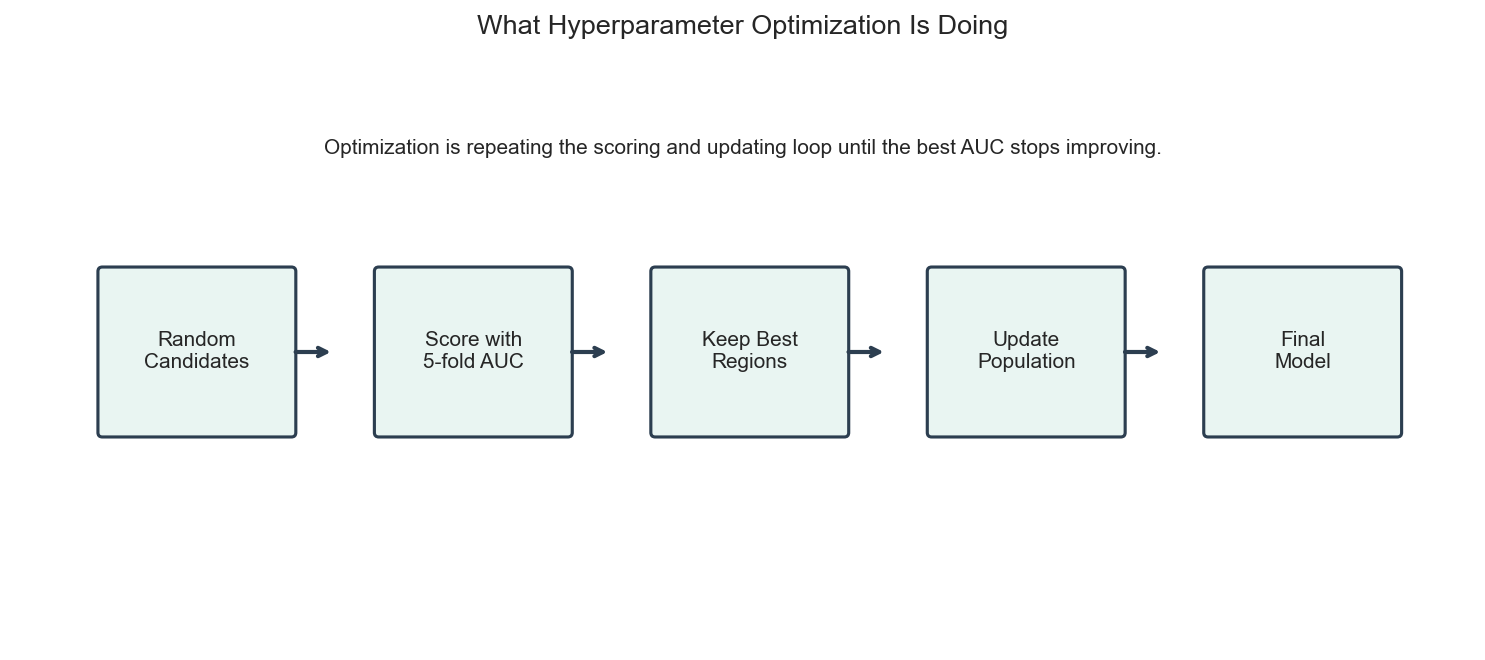

In [8]:
# Plotting the optimization workflow diagram is giving a simple visual explanation of what optimization is doing from start to finish.
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

box_positions = [0.6, 2.5, 4.4, 6.3, 8.2]
labels = ['Random\nCandidates', 'Score with\n5-fold AUC', 'Keep Best\nRegions', 'Update\nPopulation', 'Final\nModel']

for x, label in zip(box_positions, labels):
    rect = mpatches.FancyBboxPatch((x, 1.45), 1.3, 1.1, boxstyle='round,pad=0.03', facecolor='#E9F5F2', edgecolor='#2C3E50', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.65, 2.0, label, ha='center', va='center', fontsize=10)

for x in box_positions[:-1]:
    ax.annotate('', xy=(x + 1.6, 2.0), xytext=(x + 1.3, 2.0), arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2))

ax.text(5.0, 3.35, 'Optimization is repeating the scoring and updating loop until the best AUC stops improving.', ha='center', fontsize=10)
ax.set_title('What Hyperparameter Optimization Is Doing', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('images/optimization/01_what_is_optimization_diagram.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Optimization Diagram
This diagram is showing the search loop in plain form. The optimizer starts with random settings, scores them, keeps the better regions, updates the population, and repeats that cycle until a best answer is found. This matters because the rest of the notebook is following this same logic, just with different nature-inspired update rules.


In [9]:
# Printing the search-space setup table is showing the starting points and marked optimum used in the contour illustration.
search_space_df = pd.DataFrame({
    'Point': ['Start A', 'Start B', 'Start C', 'Global optimum'],
    'X': [-2.0, 1.8, 2.2, 0.7],
    'Y': [-1.5, -2.2, 1.7, 0.9],
    'Role': ['Random starting candidate', 'Random starting candidate', 'Random starting candidate', 'Best point on the landscape']
})
print(search_space_df.to_string(index=False))


         Point    X    Y                        Role
       Start A -2.0 -1.5   Random starting candidate
       Start B  1.8 -2.2   Random starting candidate
       Start C  2.2  1.7   Random starting candidate
Global optimum  0.7  0.9 Best point on the landscape


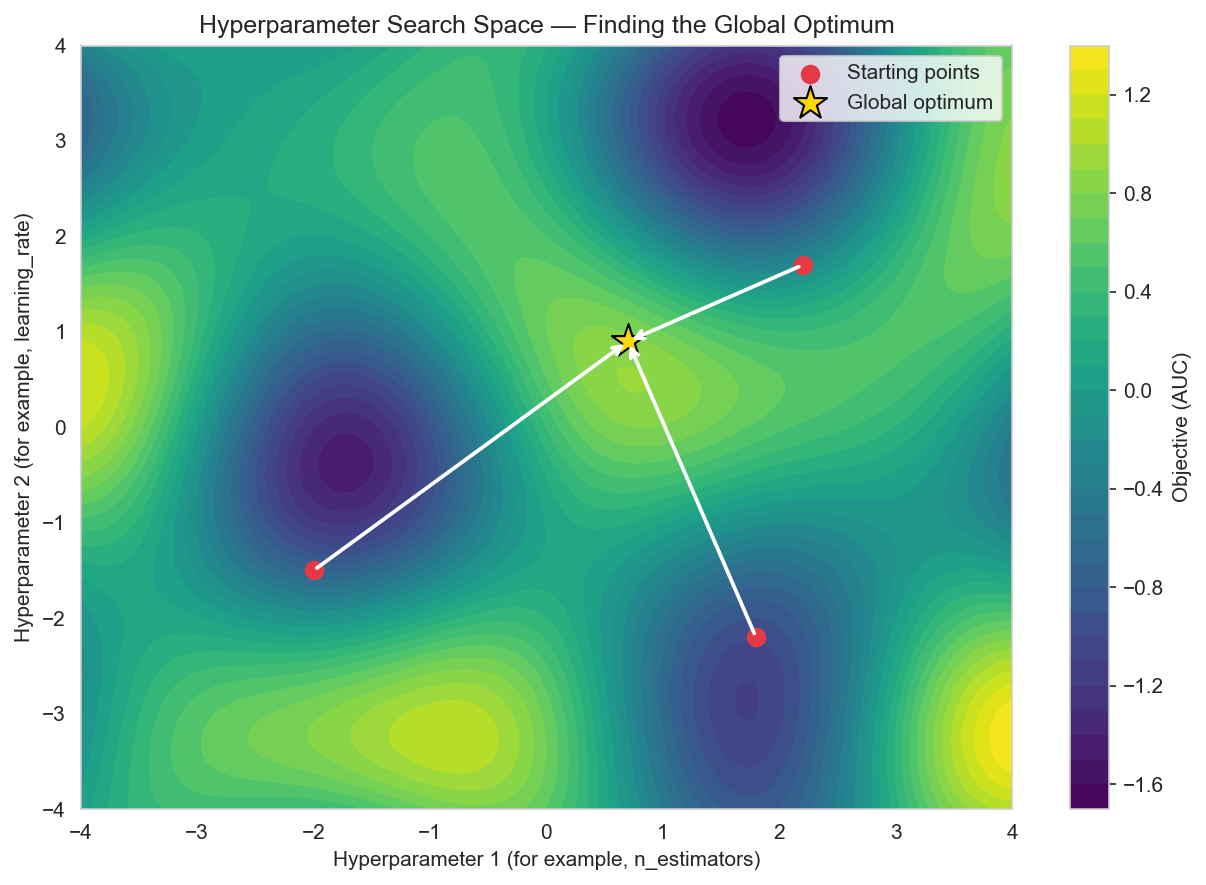

In [10]:
# Plotting the search-space illustration is showing how the optimizer moves over a surface with local peaks and one best region.
x = np.linspace(-4, 4, 300)
y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y) + 0.4 * np.cos(1.7 * X) + 0.3 * np.sin(1.4 * Y)
Z = gaussian_filter(Z, sigma=1.2)

start_points = np.array([[-2.0, -1.5], [1.8, -2.2], [2.2, 1.7]])
optimum = np.array([0.7, 0.9])

fig, ax = plt.subplots(figsize=(8.5, 6.0))
contour = ax.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax, label='Objective (AUC)')
ax.scatter(start_points[:, 0], start_points[:, 1], color=COLORS['best'], s=70, label='Starting points')
ax.scatter(optimum[0], optimum[1], color='gold', edgecolor='black', marker='*', s=280, label='Global optimum')
for point in start_points:
    ax.annotate('', xy=(optimum[0], optimum[1]), xytext=(point[0], point[1]), arrowprops=dict(arrowstyle='->', color='white', lw=1.8))
ax.set_xlabel('Hyperparameter 1 (for example, n_estimators)')
ax.set_ylabel('Hyperparameter 2 (for example, learning_rate)')
ax.set_title('Hyperparameter Search Space — Finding the Global Optimum')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('images/optimization/02_search_space_illustration.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Search-Space Figure
This chart is showing the search problem as a landscape. High areas mean better AUC. The starting points are beginning in different places and moving toward the best region. This matters because WaO, RSO, and CSO are all different ways of moving through this kind of landscape.


### Walrus Optimization Algorithm (WaO)
The Walrus Optimization Algorithm (WaO) is inspired by the social and survival behaviour of walruses. The idea is simple: walruses sometimes gather around the safest and strongest place, and sometimes explore more freely while foraging. In optimization terms, those two behaviours become exploitation and exploration.

Let the population at iteration $t$ be

$$
X_i^{(t)} \in \mathbb{R}^d, \quad i = 1,2,\ldots,N,
$$

where each vector contains one full hyperparameter setting. The best solution found so far is written as $X_{\text{best}}^{(t)}$.

**Phase 1 — Resting (exploitation).** In the resting phase, a walrus moves toward the best known position:

$$
X_i^{(t+1)} = X_i^{(t)} + r_1 \cdot \left(X_{\text{best}}^{(t)} - I \cdot X_i^{(t)}\right),
$$

where

$$
r_1 \sim \mathcal{U}(0,1), \quad I \in \{1,2\}.
$$

**Phase 2 — Foraging (exploration).** In the foraging phase, a walrus moves with respect to a randomly selected peer:

$$
X_i^{(t+1)} = X_i^{(t)} + r_2 \cdot \left(X_{\text{rand}}^{(t)} - I \cdot X_i^{(t)}\right),
$$

where

$$
r_2 \sim \mathcal{U}(0,1).
$$

**Boundary handling.** Every candidate is clipped to the valid search range after each update:

$$
X_i^{(t+1)} = \min\left(\max\left(X_i^{(t+1)}, \theta^{\min}\right), \theta^{\max}\right).
$$

WaO is usually expected to converge in a balanced way because it has one phase that pulls hard toward the best solution and another that keeps new areas in play.

**Simple meaning:** WaO keeps switching between “move toward the best answer found so far” and “try a different direction using another candidate.” That balance can help it search widely without losing focus.


In [11]:
# Printing the WaO phase table is showing the exact visual components used in the next illustration.
wao_phase_df = pd.DataFrame({
    'Phase': ['Resting', 'Foraging'],
    'Search role': ['Exploitation', 'Exploration'],
    'Direction': ['Toward global best', 'Toward a random peer'],
    'Expected effect': ['Faster local improvement', 'More search diversity']
})
print(wao_phase_df.to_string(index=False))


   Phase  Search role            Direction          Expected effect
 Resting Exploitation   Toward global best Faster local improvement
Foraging  Exploration Toward a random peer    More search diversity


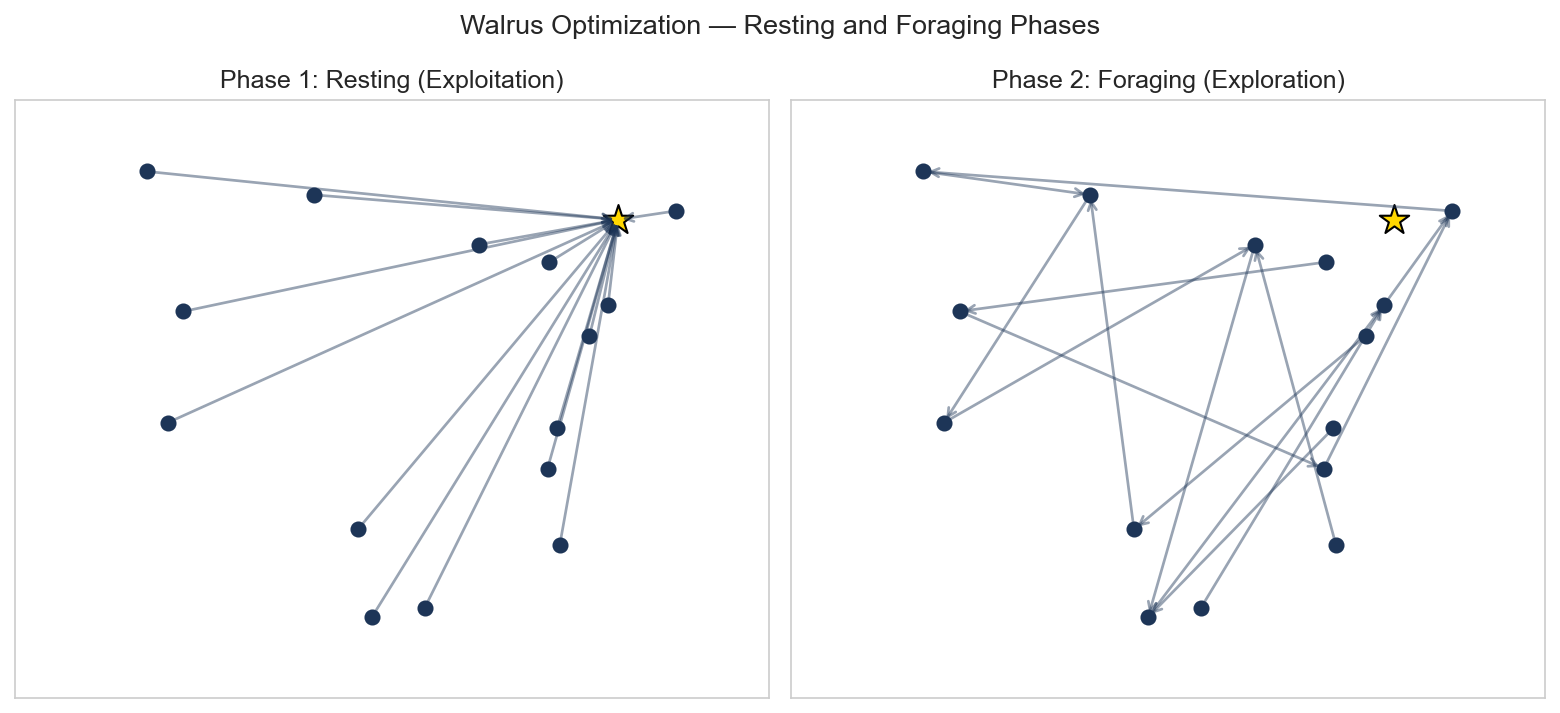

In [12]:
# Plotting the WaO behaviour illustration is showing the difference between its resting and foraging phases.
rng = np.random.default_rng(RANDOM_STATE)
points = rng.uniform(0.5, 4.5, size=(15, 2))
best_point = np.array([4.0, 4.0])
peer_targets = points[rng.integers(0, len(points), size=len(points))]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

axes[0].scatter(points[:, 0], points[:, 1], color=COLORS['wao'], s=45)
axes[0].scatter(best_point[0], best_point[1], color='gold', edgecolor='black', marker='*', s=220)
for p in points:
    axes[0].annotate('', xy=best_point, xytext=p, arrowprops=dict(arrowstyle='->', color=COLORS['wao'], alpha=0.45, lw=1.3))
axes[0].set_title('Phase 1: Resting (Exploitation)')

axes[1].scatter(points[:, 0], points[:, 1], color=COLORS['wao'], s=45)
axes[1].scatter(best_point[0], best_point[1], color='gold', edgecolor='black', marker='*', s=220)
for p, peer in zip(points, peer_targets):
    axes[1].annotate('', xy=peer, xytext=p, arrowprops=dict(arrowstyle='->', color=COLORS['wao'], alpha=0.45, lw=1.3))
axes[1].set_title('Phase 2: Foraging (Exploration)')

for ax in axes:
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Walrus Optimization — Resting and Foraging Phases', fontsize=13)
plt.tight_layout()
plt.savefig('images/optimization/03_wao_behaviour_illustration.png', bbox_inches='tight')
plt.show()


### Simple Reading of the WaO Figure
The left panel is showing walruses closing in on the best answer. The right panel is showing them testing other directions through random peers. This matters because good optimization needs both behaviours: one to improve what already looks good, and one to stop the search from becoming trapped too early.


### Rat Swarm Optimization (RSO)
Rat Swarm Optimization (RSO) is inspired by the way rats move when they chase and attack a target. The key idea is that the swarm becomes more focused over time. Early iterations explore more widely, while later iterations concentrate on the best region already found.

The attack phase is written as

$$
X_i^{(t+1)} = X_i^{(t)} + A \cdot r_1 \cdot \left(X_{\text{best}}^{(t)} - X_i^{(t)}\right),
$$

where

$$
A = 2 - \frac{2t}{T_{\max}}
$$

is a linearly decreasing control term and

$$
r_1 \sim \mathcal{U}(0,1).
$$

The chase phase is written as

$$
X_i^{(t+1)} = r_2 \cdot X_{\text{best}}^{(t)} - r_3 \cdot X_i^{(t)},
$$

where

$$
r_2, r_3 \sim \mathcal{U}(0,2).
$$

The decreasing value of $A$ is important. When $t$ is small, $A$ is close to $2$, so movement is larger and search is wider. When $t$ gets closer to $T_{\max}$, $A$ moves toward $0$, so the swarm tightens around the best region.

**Simple meaning:** RSO starts with stronger movement and then becomes more careful later in the run. That makes it a fairly steady optimizer, although sometimes it may settle too soon if the search space is very rough.


In [13]:
# Printing the RSO phase table is showing the exact visual components used in the next illustration.
rso_phase_df = pd.DataFrame({
    'Phase': ['Attack', 'Chase'],
    'Search role': ['Focused exploitation', 'Predictive exploration'],
    'Direction': ['Directly toward best solution', 'Toward a predicted target position'],
    'Expected effect': ['Strong local improvement', 'Forward-looking search']
})
print(rso_phase_df.to_string(index=False))


 Phase            Search role                          Direction          Expected effect
Attack   Focused exploitation      Directly toward best solution Strong local improvement
 Chase Predictive exploration Toward a predicted target position   Forward-looking search


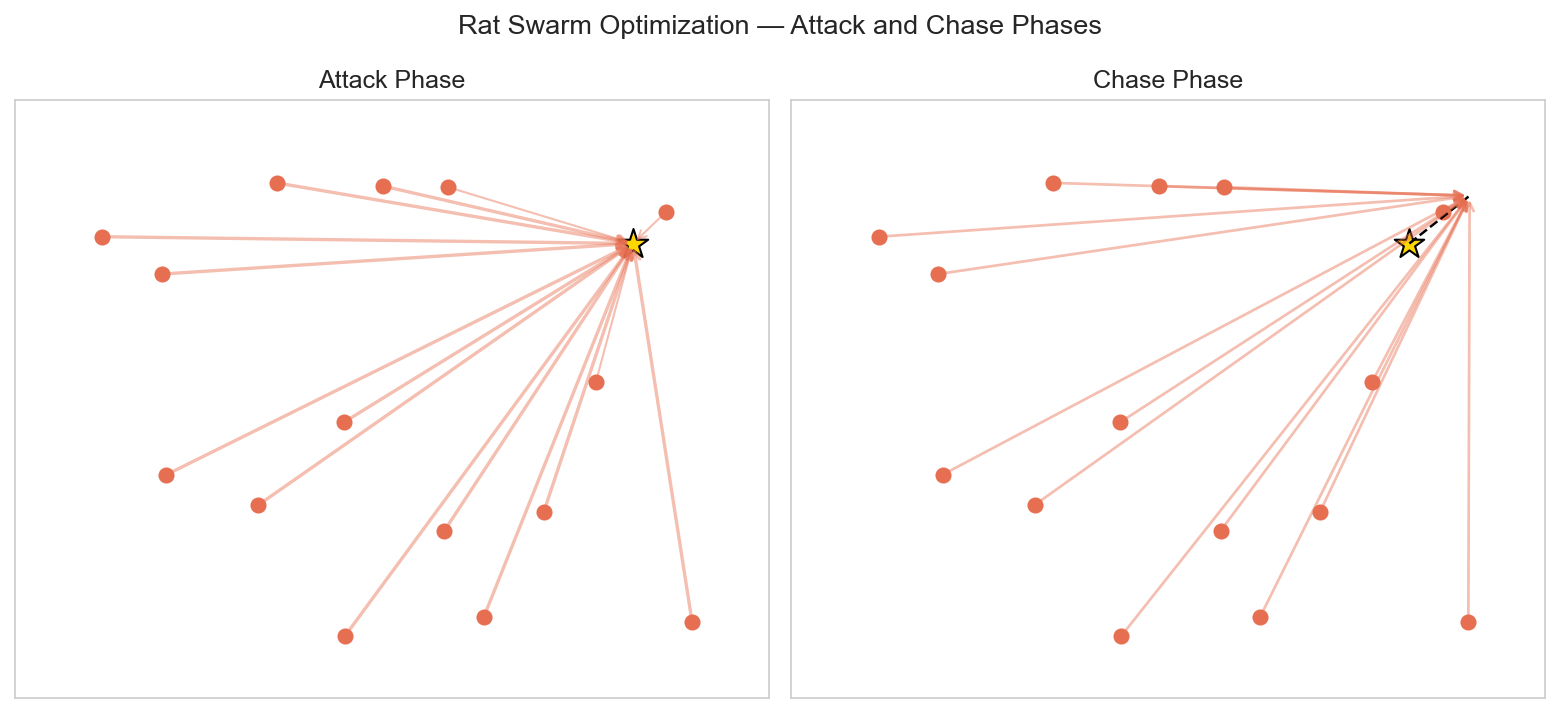

In [14]:
# Plotting the RSO behaviour illustration is showing the difference between its attack and chase phases.
rng = np.random.default_rng(RANDOM_STATE + 1)
rats = rng.uniform(0.5, 4.5, size=(15, 2))
food = np.array([4.1, 3.8])
future_food = np.array([4.5, 4.2])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

axes[0].scatter(rats[:, 0], rats[:, 1], color=COLORS['rso'], s=45)
axes[0].scatter(food[0], food[1], color='gold', edgecolor='black', marker='*', s=220)
for p in rats:
    lw = 1.6 if np.linalg.norm(food - p) > 1.5 else 1.0
    axes[0].annotate('', xy=food, xytext=p, arrowprops=dict(arrowstyle='->', color=COLORS['rso'], alpha=0.45, lw=lw))
axes[0].set_title('Attack Phase')

axes[1].scatter(rats[:, 0], rats[:, 1], color=COLORS['rso'], s=45)
axes[1].scatter(food[0], food[1], color='gold', edgecolor='black', marker='*', s=220)
axes[1].plot([food[0], future_food[0]], [food[1], future_food[1]], linestyle='--', color='black', lw=1.2)
for p in rats:
    axes[1].annotate('', xy=future_food, xytext=p, arrowprops=dict(arrowstyle='->', color=COLORS['rso'], alpha=0.45, lw=1.3))
axes[1].set_title('Chase Phase')

for ax in axes:
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Rat Swarm Optimization — Attack and Chase Phases', fontsize=13)
plt.tight_layout()
plt.savefig('images/optimization/04_rso_behaviour_illustration.png', bbox_inches='tight')
plt.show()


### Simple Reading of the RSO Figure
The left panel is showing the swarm pushing toward the best solution. The right panel is showing a more forward-looking chase step. This matters because RSO is not only reacting to the best point; it is also trying to reposition itself in a way that can keep the search moving.


### Cat Swarm Optimization (CSO)
Cat Swarm Optimization (CSO) is built around two cat behaviours: tracing and seeking. Tracing is the more directed mode, where a cat keeps moving with memory and momentum. Seeking is the more exploratory mode, where small local alternatives are tested before choosing the best one.

In tracing mode, velocity is updated first:

$$
V_i^{(t+1)} = w \cdot V_i^{(t)} + r_1 \cdot c_1 \cdot \left(X_{\text{best}}^{(t)} - X_i^{(t)}\right),
$$

and then position is updated as

$$
X_i^{(t+1)} = X_i^{(t)} + V_i^{(t+1)}.
$$

Here, $w$ is an inertia term that decays over time, $c_1$ is an acceleration constant, and $r_1 \sim \mathcal{U}(0,1)$.

In seeking mode, a small pool of nearby candidates is created:

$$
X_{\text{candidate}} = X_i^{(t)} + \Delta \cdot CDC \cdot X_i^{(t)},
$$

where $\Delta \sim \mathcal{U}(-1,1)$ and $CDC$ controls how many dimensions are changed. The best candidate from that local pool is kept.

The mixing ratio $MR$ decides how much of the population is in seeking mode at a given time. In this notebook, the standard value

$$
MR = 0.2
$$

means 20% of the cats explore through seeking mode while the rest continue tracing.

**Simple meaning:** CSO mixes smooth movement with short local testing. It often gives steady convergence, but its exploration can be softer than WaO if the landscape is very hard.


In [15]:
# Printing the CSO phase table is showing the exact visual components used in the next illustration.
cso_phase_df = pd.DataFrame({
    'Phase': ['Tracing', 'Seeking'],
    'Search role': ['Momentum-based exploitation', 'Local candidate exploration'],
    'Direction': ['Velocity update toward best solution', 'Short candidate moves around current point'],
    'Expected effect': ['Smooth convergence', 'Local refinement and checking']
})
print(cso_phase_df.to_string(index=False))


  Phase                 Search role                                  Direction               Expected effect
Tracing Momentum-based exploitation       Velocity update toward best solution            Smooth convergence
Seeking Local candidate exploration Short candidate moves around current point Local refinement and checking


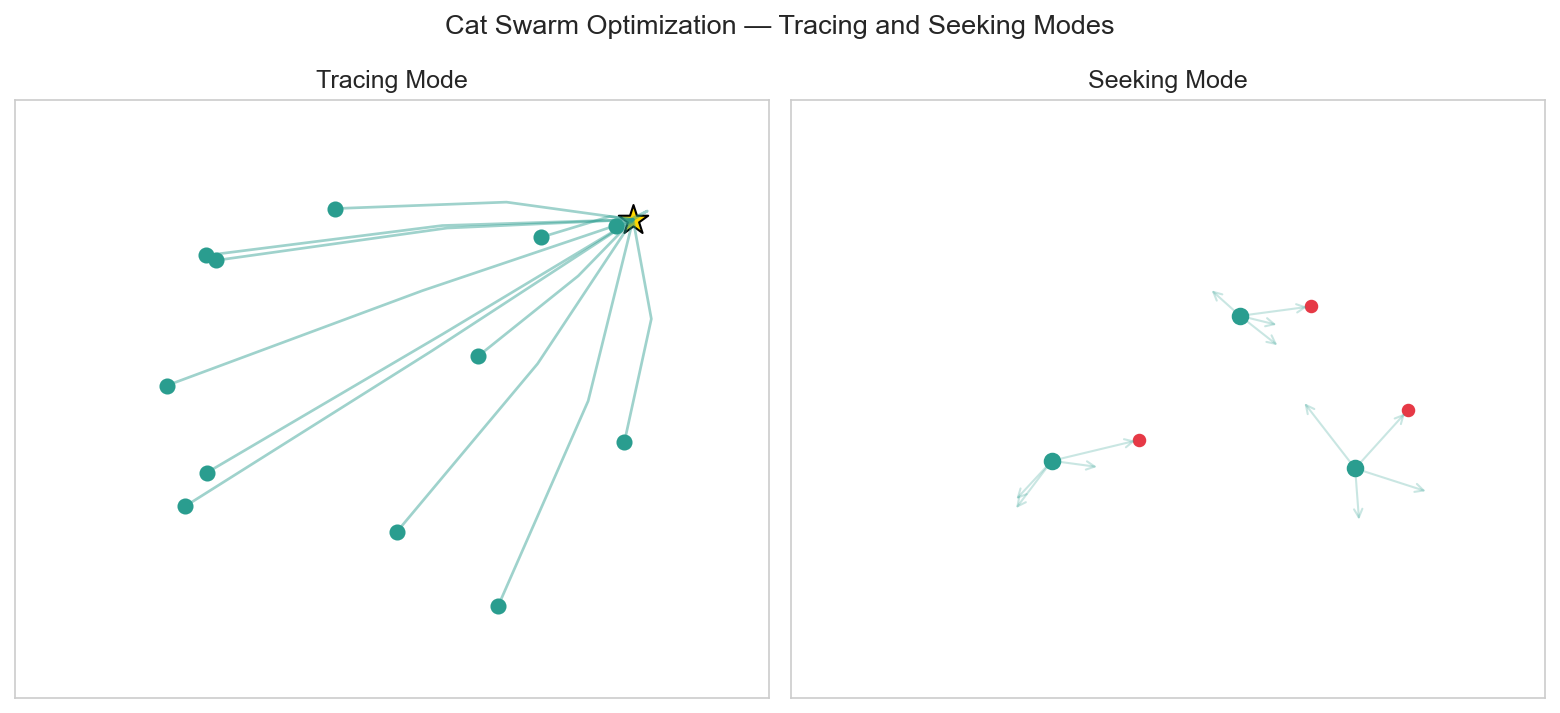

In [16]:
# Plotting the CSO behaviour illustration is showing the difference between its tracing and seeking modes.
rng = np.random.default_rng(RANDOM_STATE + 2)
tracing_points = rng.uniform(0.7, 4.2, size=(12, 2))
seeking_points = rng.uniform(1.2, 3.8, size=(3, 2))
best_point = np.array([4.1, 4.0])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

axes[0].scatter(tracing_points[:, 0], tracing_points[:, 1], color=COLORS['cso'], s=45)
axes[0].scatter(best_point[0], best_point[1], color='gold', edgecolor='black', marker='*', s=220)
for p in tracing_points:
    mid = (p + best_point) / 2 + np.array([0.15, 0.10])
    axes[0].plot([p[0], mid[0], best_point[0]], [p[1], mid[1], best_point[1]], color=COLORS['cso'], alpha=0.45, lw=1.3)
axes[0].set_title('Tracing Mode')

axes[1].scatter(seeking_points[:, 0], seeking_points[:, 1], color=COLORS['cso'], s=55)
for p in seeking_points:
    candidates = p + rng.uniform(-0.6, 0.6, size=(4, 2))
    best_local = candidates[np.argmin(np.linalg.norm(candidates - best_point, axis=1))]
    for cand in candidates:
        axes[1].annotate('', xy=cand, xytext=p, arrowprops=dict(arrowstyle='->', color=COLORS['cso'], alpha=0.25, lw=1.0))
    axes[1].scatter(best_local[0], best_local[1], color=COLORS['best'], s=30)
axes[1].set_title('Seeking Mode')

for ax in axes:
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Cat Swarm Optimization — Tracing and Seeking Modes', fontsize=13)
plt.tight_layout()
plt.savefig('images/optimization/05_cso_behaviour_illustration.png', bbox_inches='tight')
plt.show()


### Simple Reading of the CSO Figure
The left panel is showing smooth movement with memory. The right panel is showing short local trials around a current point. This matters because CSO tries to stay stable while still checking nearby alternatives before committing to a final move.


### Algorithm Comparison Summary

| Property | WaO | RSO | CSO |
| --- | --- | --- | --- |
| Biological inspiration | Arctic walrus resting and foraging | Rat swarm attack and chase | Cat tracing and seeking |
| Proposed by | Trojovský and Dehghani (2023) | Dhiman and Kumar (2020) | Chu, Tsai, and Pan (2006) |
| Main exploration move | Random foraging toward peers | Chase step with predictive repositioning | Seeking mode with candidate memory pool |
| Main exploitation move | Resting step toward the best solution | Attack step with decaying control | Tracing step with velocity and inertia |
| Exploration-exploitation switch | Peer-quality driven | Controlled by a decaying coefficient | Controlled by a mixing ratio |
| Main strength | Balanced and adaptive | Reliable and predictable | Smooth convergence with memory |
| Main weakness | May oscillate late in the run | May settle early in rugged spaces | May explore too gently in hard spaces |

The three algorithms are expected to produce different convergence shapes. WaO often balances exploration and exploitation well. RSO usually becomes more focused over time because of its decaying coefficient. CSO usually moves more smoothly because of velocity memory. Comparing these curves is part of the thesis contribution because it shows which search style works best for this PCOS ensemble problem.


## Section 3 — Hyperparameter Search Space Definition

### Defining the Search Space
The optimization is searching over a 9-dimensional hyperparameter space. Some dimensions are integers and some are continuous. The optimizers treat all positions as numeric vectors during movement, then the notebook rounds integer parameters and clips all values back to their valid ranges before scoring a candidate.

| Hyperparameter | Model component | Type | Lower | Upper | Why it matters |
| --- | --- | --- | --- | --- | --- |
| `rf_n_estimators` | Random Forest base learner | Integer | `50` | `500` | More trees usually give more stable predictions. |
| `rf_max_depth` | Random Forest base learner | Integer | `2` | `20` | This controls how complex each tree can become. |
| `rf_min_samples_split` | Random Forest base learner | Integer | `2` | `20` | This controls how many patients are needed before a split is allowed. |
| `xgb_n_estimators` | XGBoost base learner | Integer | `50` | `400` | This controls the number of boosting rounds. |
| `xgb_learning_rate` | XGBoost base learner | Float | `0.01` | `0.30` | This controls the step size of each new boosting round. |
| `xgb_max_depth` | XGBoost base learner | Integer | `2` | `10` | This controls tree complexity. |
| `xgb_subsample` | XGBoost base learner | Float | `0.50` | `1.00` | This controls how much of the training data each tree sees. |
| `meta_C` | Logistic Regression meta-learner | Float | `0.01` | `10.0` | This controls regularization strength when the meta-learner is LR. |
| `meta_n_estimators` | Random Forest or XGBoost meta-learner | Integer | `50` | `300` | This controls the size of a tree-based meta-learner. |


In [17]:
# Defining the search bounds is locking the exact hyperparameter space explored by all three optimizers.
PARAM_NAMES = ['rf_n_estimators', 'rf_max_depth', 'rf_min_samples_split', 'xgb_n_estimators', 'xgb_learning_rate', 'xgb_max_depth', 'xgb_subsample', 'meta_C', 'meta_n_estimators']
LOWER_BOUNDS = np.array([50, 2, 2, 50, 0.01, 2, 0.50, 0.01, 50], dtype=float)
UPPER_BOUNDS = np.array([500, 20, 20, 400, 0.30, 10, 1.00, 10.0, 300], dtype=float)
PARAM_TYPES = ['int', 'int', 'int', 'int', 'float', 'int', 'float', 'float', 'int']
N_PARAMS = len(PARAM_NAMES)
bounds_df = pd.DataFrame({'Parameter': PARAM_NAMES, 'Lower Bound': LOWER_BOUNDS, 'Upper Bound': UPPER_BOUNDS, 'Type': PARAM_TYPES})
print(f'Search space dimensionality: {N_PARAMS}')
print(bounds_df.to_string(index=False))


Search space dimensionality: 9
           Parameter  Lower Bound  Upper Bound  Type
     rf_n_estimators        50.00        500.0   int
        rf_max_depth         2.00         20.0   int
rf_min_samples_split         2.00         20.0   int
    xgb_n_estimators        50.00        400.0   int
   xgb_learning_rate         0.01          0.3 float
       xgb_max_depth         2.00         10.0   int
       xgb_subsample         0.50          1.0 float
              meta_C         0.01         10.0 float
   meta_n_estimators        50.00        300.0   int


In [18]:
# Defining helper functions is making the optimizer code shorter, safer, and easier to read.
def decode_params(params_vector):
    return {
        'rf_n_estimators': int(np.clip(round(params_vector[0]), 50, 500)),
        'rf_max_depth': int(np.clip(round(params_vector[1]), 2, 20)),
        'rf_min_samples_split': int(np.clip(round(params_vector[2]), 2, 20)),
        'xgb_n_estimators': int(np.clip(round(params_vector[3]), 50, 400)),
        'xgb_learning_rate': float(np.clip(params_vector[4], 0.01, 0.30)),
        'xgb_max_depth': int(np.clip(round(params_vector[5]), 2, 10)),
        'xgb_subsample': float(np.clip(params_vector[6], 0.50, 1.00)),
        'meta_C': float(np.clip(params_vector[7], 0.01, 10.0)),
        'meta_n_estimators': int(np.clip(round(params_vector[8]), 50, 300)),
    }

def build_base_learners(decoded):
    lr_candidate = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
    rf_candidate = RandomForestClassifier(
        n_estimators=decoded['rf_n_estimators'],
        max_depth=decoded['rf_max_depth'],
        min_samples_split=decoded['rf_min_samples_split'],
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_candidate = XGBClassifier(
        n_estimators=decoded['xgb_n_estimators'],
        learning_rate=decoded['xgb_learning_rate'],
        max_depth=decoded['xgb_max_depth'],
        subsample=decoded['xgb_subsample'],
        colsample_bytree=0.8,
        scale_pos_weight=1.0,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
    return lr_candidate, rf_candidate, xgb_candidate

def build_meta_learner(stack_family, decoded):
    if stack_family == 'lr':
        return LogisticRegression(C=decoded['meta_C'], max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    if stack_family == 'rf':
        return RandomForestClassifier(n_estimators=decoded['meta_n_estimators'], class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    return XGBClassifier(n_estimators=decoded['meta_n_estimators'], learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)

def generate_oof_matrix(X_train, y_train, decoded):
    inner_cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_candidate = np.zeros((X_train.shape[0], 3))
    fill_counts = np.zeros(X_train.shape[0], dtype=int)
    for tr_idx, val_idx in inner_cv.split(X_train, y_train):
        lr_candidate, rf_candidate, xgb_candidate = build_base_learners(decoded)
        for col_idx, model in enumerate([lr_candidate, rf_candidate, xgb_candidate]):
            model.fit(X_train[tr_idx], y_train[tr_idx])
            oof_candidate[val_idx, col_idx] = model.predict_proba(X_train[val_idx])[:, 1]
        fill_counts[val_idx] += 1
    if not np.all(fill_counts == 1):
        raise ValueError('OOF generation failed because some rows were not filled exactly once.')
    return oof_candidate

def evaluate_prediction_set(name, y_true, y_pred, y_proba):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='binary'),
        'recall': recall_score(y_true, y_pred, average='binary'),
        'f1': f1_score(y_true, y_pred, average='binary'),
        'auc': roc_auc_score(y_true, y_proba),
    }

def build_test_meta_features(X_train, y_train, X_test, decoded):
    lr_full, rf_full, xgb_full = build_base_learners(decoded)
    lr_full.fit(X_train, y_train)
    rf_full.fit(X_train, y_train)
    xgb_full.fit(X_train, y_train)
    test_meta = np.column_stack([lr_full.predict_proba(X_test)[:, 1], rf_full.predict_proba(X_test)[:, 1], xgb_full.predict_proba(X_test)[:, 1]])
    return (lr_full, rf_full, xgb_full), test_meta

def build_optimized_ensemble(params_vector, X_train, y_train, X_test, y_test, stack_family, name, feature_names):
    decoded = decode_params(params_vector)
    oof_candidate = generate_oof_matrix(X_train, y_train, decoded)
    base_models, test_meta = build_test_meta_features(X_train, y_train, X_test, decoded)
    meta_model = build_meta_learner(stack_family, decoded)
    meta_model.fit(oof_candidate, y_train)
    y_proba = meta_model.predict_proba(test_meta)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    results = evaluate_prediction_set(name, y_test, y_pred, y_proba)
    artifact = {
        'stack_family': stack_family,
        'params_vector': [float(v) for v in params_vector],
        'decoded_params': decoded,
        'feature_names': list(feature_names),
        'meta_feature_order': ['LR_prob', 'RF_prob', 'XGB_prob'],
        'base_models': {'lr': base_models[0], 'rf': base_models[1], 'xgb': base_models[2]},
        'meta_model': meta_model,
        'threshold': 0.5,
        'test_results': results,
    }
    return artifact, results


In [19]:
# Defining the objective function is making one score that all three optimizers will try to minimize.
def objective(params_vector, X_train, y_train, stack_family='lr'):
    decoded = decode_params(params_vector)
    oof_candidate = generate_oof_matrix(X_train, y_train, decoded)
    meta = build_meta_learner(stack_family, decoded)
    inner_cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    auc_scores = cross_val_score(meta, oof_candidate, y_train, cv=inner_cv, scoring='roc_auc')
    return -auc_scores.mean()

test_objective_value = objective(LOWER_BOUNDS, X1_train, y1_train, stack_family=stack_family_m1)
print(f'Test objective call (negative AUC): {test_objective_value:.4f}')
print(f'Test objective call (AUC): {-test_objective_value:.4f}')


Test objective call (negative AUC): -0.9067
Test objective call (AUC): 0.9067


## Section 4 — Implementing the Three Optimizers

### Implementation Note
The three optimizers are being implemented from scratch in Python. This matters for the thesis because it shows the exact mechanics of each algorithm, allows full convergence tracking, and avoids hiding the search logic inside a black-box library. NumPy is handling the vector math, while SciPy is only helping with mathematical visual support. The optimizer engine itself is fully handwritten here.

To keep runtime practical on local hardware, this notebook is using a reduced population size of 5 candidates, up to 10 iterations, and an early-stopping rule. The search stops early if the AUC plateaus for several iterations or if the optimizer already beats the stacking baseline by a small useful margin.


In [20]:
# Implementing Walrus Optimization is creating the first full metaheuristic search routine used in this notebook.
def walrus_optimization(obj_func, lb, ub, n_pop, n_iter, target_auc=None, patience=EARLY_STOP_PATIENCE, min_delta=MIN_DELTA, verbose=True):
    n_dim = len(lb)
    population = lb + np.random.rand(n_pop, n_dim) * (ub - lb)
    fitness = np.array([obj_func(ind) for ind in population], dtype=float)
    best_idx = np.argmin(fitness)
    best_pos = population[best_idx].copy()
    best_fit = float(fitness[best_idx])
    history = [best_fit]
    no_improve_count = 0
    for t in range(1, n_iter + 1):
        for i in range(n_pop):
            I = np.random.randint(1, 3)
            r1 = np.random.rand(n_dim)
            candidate = population[i] + r1 * (best_pos - I * population[i])
            candidate = np.clip(candidate, lb, ub)
            cand_fit = float(obj_func(candidate))
            if cand_fit < fitness[i]:
                population[i] = candidate
                fitness[i] = cand_fit
            rand_idx = np.random.randint(0, n_pop)
            r2 = np.random.rand(n_dim)
            candidate2 = population[i] + r2 * (population[rand_idx] - I * population[i])
            candidate2 = np.clip(candidate2, lb, ub)
            cand_fit2 = float(obj_func(candidate2))
            if cand_fit2 < fitness[i]:
                population[i] = candidate2
                fitness[i] = cand_fit2
        current_best_idx = np.argmin(fitness)
        previous_best = best_fit
        if fitness[current_best_idx] < best_fit:
            best_fit = float(fitness[current_best_idx])
            best_pos = population[current_best_idx].copy()
        history.append(best_fit)
        if previous_best - best_fit > min_delta:
            no_improve_count = 0
        else:
            no_improve_count += 1
        if verbose and t % 5 == 0:
            print(f'  WaO Iteration {t:3d}/{n_iter} | Best AUC: {-best_fit:.4f}')
        if t >= MIN_ITER_BEFORE_STOP and target_auc is not None and (-best_fit) >= target_auc:
            if verbose:
                print(f'  WaO early stopping: target AUC reached at iteration {t}.')
            break
        if t >= MIN_ITER_BEFORE_STOP and no_improve_count >= patience:
            if verbose:
                print(f'  WaO early stopping: no meaningful improvement for {patience} iterations.')
            break
    return best_pos, -best_fit, np.array(history, dtype=float)

print('Walrus Optimization function is defined.')


Walrus Optimization function is defined.


In [21]:
# Implementing Rat Swarm Optimization is creating the second full metaheuristic search routine used in this notebook.
def rat_swarm_optimization(obj_func, lb, ub, n_pop, n_iter, target_auc=None, patience=EARLY_STOP_PATIENCE, min_delta=MIN_DELTA, verbose=True):
    n_dim = len(lb)
    population = lb + np.random.rand(n_pop, n_dim) * (ub - lb)
    fitness = np.array([obj_func(ind) for ind in population], dtype=float)
    best_idx = np.argmin(fitness)
    best_pos = population[best_idx].copy()
    best_fit = float(fitness[best_idx])
    history = [best_fit]
    no_improve_count = 0
    for t in range(1, n_iter + 1):
        A = 2 - 2 * (t / n_iter)
        for i in range(n_pop):
            r1 = np.random.rand(n_dim)
            r2 = 2 * np.random.rand(n_dim)
            r3 = 2 * np.random.rand(n_dim)
            if np.random.rand() < 0.5:
                candidate = population[i] + A * r1 * (best_pos - population[i])
            else:
                candidate = r2 * best_pos - r3 * population[i]
            candidate = np.clip(candidate, lb, ub)
            cand_fit = float(obj_func(candidate))
            if cand_fit < fitness[i]:
                population[i] = candidate
                fitness[i] = cand_fit
        current_best_idx = np.argmin(fitness)
        previous_best = best_fit
        if fitness[current_best_idx] < best_fit:
            best_fit = float(fitness[current_best_idx])
            best_pos = population[current_best_idx].copy()
        history.append(best_fit)
        if previous_best - best_fit > min_delta:
            no_improve_count = 0
        else:
            no_improve_count += 1
        if verbose and t % 5 == 0:
            print(f'  RSO Iteration {t:3d}/{n_iter} | Best AUC: {-best_fit:.4f}')
        if t >= MIN_ITER_BEFORE_STOP and target_auc is not None and (-best_fit) >= target_auc:
            if verbose:
                print(f'  RSO early stopping: target AUC reached at iteration {t}.')
            break
        if t >= MIN_ITER_BEFORE_STOP and no_improve_count >= patience:
            if verbose:
                print(f'  RSO early stopping: no meaningful improvement for {patience} iterations.')
            break
    return best_pos, -best_fit, np.array(history, dtype=float)

print('Rat Swarm Optimization function is defined.')


Rat Swarm Optimization function is defined.


In [22]:
# Implementing Cat Swarm Optimization is creating the third full metaheuristic search routine used in this notebook.
def cat_swarm_optimization(obj_func, lb, ub, n_pop, n_iter, target_auc=None, patience=EARLY_STOP_PATIENCE, min_delta=MIN_DELTA, verbose=True):
    n_dim = len(lb)
    MR = 0.2
    SMP = 5
    CDC = 0.3
    c1 = 2.0
    w_max = 0.9
    w_min = 0.4
    population = lb + np.random.rand(n_pop, n_dim) * (ub - lb)
    velocities = np.zeros((n_pop, n_dim))
    fitness = np.array([obj_func(ind) for ind in population], dtype=float)
    best_idx = np.argmin(fitness)
    best_pos = population[best_idx].copy()
    best_fit = float(fitness[best_idx])
    history = [best_fit]
    no_improve_count = 0
    for t in range(1, n_iter + 1):
        w = w_max - (w_max - w_min) * (t / n_iter)
        for i in range(n_pop):
            if np.random.rand() > MR:
                r1 = np.random.rand(n_dim)
                velocities[i] = w * velocities[i] + r1 * c1 * (best_pos - population[i])
                candidate = population[i] + velocities[i]
                candidate = np.clip(candidate, lb, ub)
                cand_fit = float(obj_func(candidate))
                if cand_fit < fitness[i]:
                    population[i] = candidate
                    fitness[i] = cand_fit
            else:
                candidates = []
                for _ in range(SMP):
                    dims = np.random.rand(n_dim) < CDC
                    delta = np.where(dims, (np.random.rand(n_dim) * 2 - 1) * (ub - lb) * 0.1, 0)
                    cand = np.clip(population[i] + delta, lb, ub)
                    candidates.append((float(obj_func(cand)), cand))
                best_cand = min(candidates, key=lambda x: x[0])
                if best_cand[0] < fitness[i]:
                    population[i] = best_cand[1]
                    fitness[i] = best_cand[0]
        current_best_idx = np.argmin(fitness)
        previous_best = best_fit
        if fitness[current_best_idx] < best_fit:
            best_fit = float(fitness[current_best_idx])
            best_pos = population[current_best_idx].copy()
        history.append(best_fit)
        if previous_best - best_fit > min_delta:
            no_improve_count = 0
        else:
            no_improve_count += 1
        if verbose and t % 5 == 0:
            print(f'  CSO Iteration {t:3d}/{n_iter} | Best AUC: {-best_fit:.4f}')
        if t >= MIN_ITER_BEFORE_STOP and target_auc is not None and (-best_fit) >= target_auc:
            if verbose:
                print(f'  CSO early stopping: target AUC reached at iteration {t}.')
            break
        if t >= MIN_ITER_BEFORE_STOP and no_improve_count >= patience:
            if verbose:
                print(f'  CSO early stopping: no meaningful improvement for {patience} iterations.')
            break
    return best_pos, -best_fit, np.array(history, dtype=float)

print('Cat Swarm Optimization function is defined.')


Cat Swarm Optimization function is defined.


## Section 5 — Running Optimization on Model 1

### Model 1 Optimization
This section is running all three optimizers on the non-invasive clinical feature set. Every optimizer is searching the same 9-dimensional space and using the same 5-fold AUC objective. To keep runtime practical, the search is using a smaller population, fewer iterations, and early stopping when the search becomes stable or clearly good enough.


In [23]:
# Running WaO on Model 1 is starting the first full optimizer search on the non-invasive stack.
print('Running Walrus Optimization on Model 1 — Non-Invasive Features')
print('=' * 60)
np.random.seed(RANDOM_STATE)
target_auc_m1 = baseline_stack_m1_auc + TARGET_GAIN
print(f'Target AUC for early stop: {target_auc_m1:.4f}')
start_time = time.time()
wao_m1_params, wao_m1_auc, wao_m1_history = walrus_optimization(
    obj_func=lambda p: objective(p, X1_train, y1_train, stack_family=stack_family_m1),
    lb=LOWER_BOUNDS,
    ub=UPPER_BOUNDS,
    n_pop=POP_SIZE,
    n_iter=N_EPOCHS,
    target_auc=target_auc_m1,
    verbose=True
)
wao_m1_time = time.time() - start_time
np.save('models/model1_wao_convergence.npy', wao_m1_history)
print()
print('WaO Model 1 complete.')
print(f'Best AUC found: {wao_m1_auc:.4f}')
print(f'Time taken    : {wao_m1_time:.1f} seconds')
print()
print('Best hyperparameters found by WaO for Model 1:')
for key, value in decode_params(wao_m1_params).items():
    print(f'  {key:25s}: {value}')


Running Walrus Optimization on Model 1 — Non-Invasive Features
Target AUC for early stop: 0.9133
  WaO early stopping: target AUC reached at iteration 4.

WaO Model 1 complete.
Best AUC found: 0.9510
Time taken    : 411.5 seconds

Best hyperparameters found by WaO for Model 1:
  rf_n_estimators          : 270
  rf_max_depth             : 11
  rf_min_samples_split     : 4
  xgb_n_estimators         : 262
  xgb_learning_rate        : 0.05473312558978096
  xgb_max_depth            : 2
  xgb_subsample            : 0.9720693992401739
  meta_C                   : 8.827571285980286
  meta_n_estimators        : 212


In [24]:
# Printing the WaO convergence table is showing the exact values behind the next curve.
wao_m1_conv_df = pd.DataFrame({'iteration': np.arange(len(wao_m1_history)), 'best_auc': -wao_m1_history})
wao_m1_conv_df['improvement'] = wao_m1_conv_df['best_auc'].diff().fillna(0.0)
print(wao_m1_conv_df.to_string(index=False))


 iteration  best_auc  improvement
         0  0.950612     0.000000
         1  0.950960     0.000349
         2  0.951023     0.000062
         3  0.951023     0.000000
         4  0.951023     0.000000


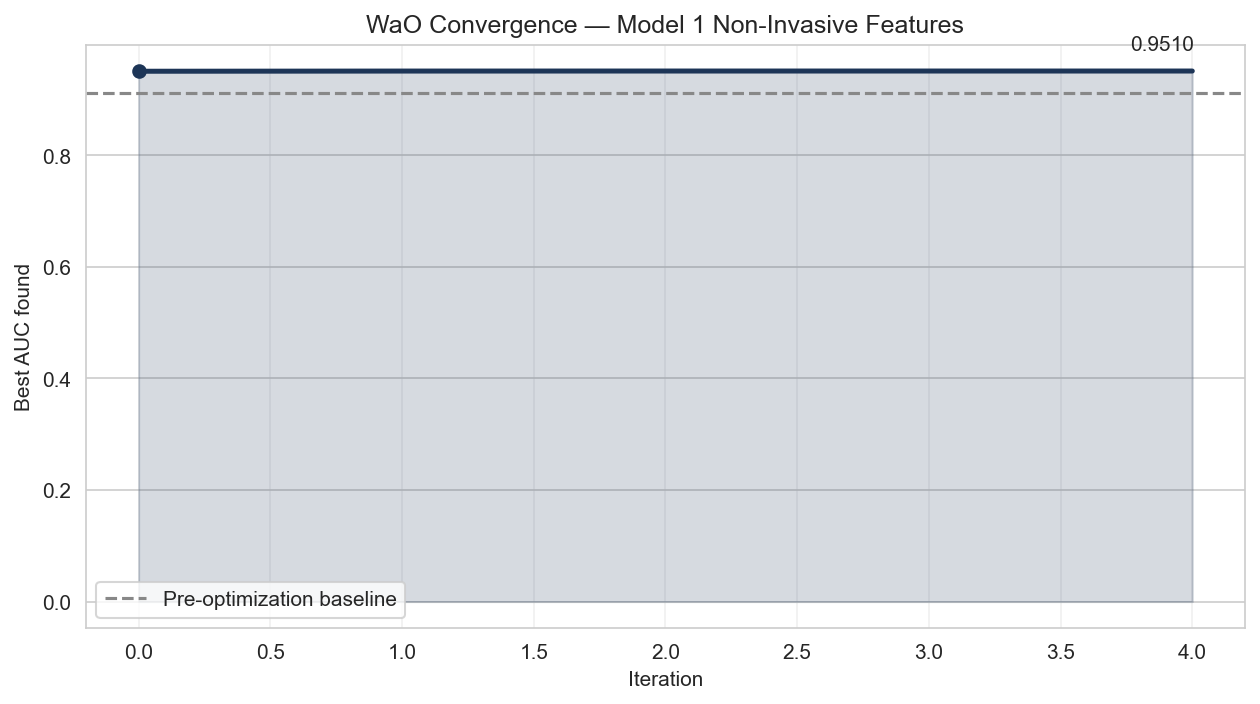

In [25]:
# Plotting the WaO convergence curve is showing how quickly and how steadily the best Model 1 score improved over time.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(wao_m1_conv_df['iteration'], wao_m1_conv_df['best_auc'], color=COLORS['wao'], lw=2.4, marker='o', markevery=5)
ax.fill_between(wao_m1_conv_df['iteration'], wao_m1_conv_df['best_auc'], color=COLORS['wao'], alpha=0.18)
ax.axhline(baseline_stack_m1_auc, color=COLORS['baseline'], linestyle='--', lw=1.5, label='Pre-optimization baseline')
ax.annotate(f"{wao_m1_conv_df['best_auc'].iloc[-1]:.4f}", xy=(wao_m1_conv_df['iteration'].iloc[-1], wao_m1_conv_df['best_auc'].iloc[-1]), xytext=(-30, 10), textcoords='offset points')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('WaO Convergence — Model 1 Non-Invasive Features')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/06_model1_wao_convergence.png', bbox_inches='tight')
plt.show()


### Simple Reading of the WaO Convergence Plot
This chart is showing how the best Model 1 AUC changed across the WaO run. A steep rise early means the optimizer is finding useful regions quickly. A flatter line later means the search is settling down near its best answer. This matters because a good optimizer should improve fast and then stabilize, not wander without progress.


In [26]:
# Running RSO on Model 1 is starting the second optimizer search on the non-invasive stack.
print('Running Rat Swarm Optimization on Model 1 — Non-Invasive Features')
print('=' * 60)
np.random.seed(RANDOM_STATE)
start_time = time.time()
rso_m1_params, rso_m1_auc, rso_m1_history = rat_swarm_optimization(
    obj_func=lambda p: objective(p, X1_train, y1_train, stack_family=stack_family_m1),
    lb=LOWER_BOUNDS,
    ub=UPPER_BOUNDS,
    n_pop=POP_SIZE,
    n_iter=N_EPOCHS,
    target_auc=target_auc_m1,
    verbose=True
)
rso_m1_time = time.time() - start_time
np.save('models/model1_rso_convergence.npy', rso_m1_history)
print()
print('RSO Model 1 complete.')
print(f'Best AUC found: {rso_m1_auc:.4f}')
print(f'Time taken    : {rso_m1_time:.1f} seconds')
print()
print('Best hyperparameters found by RSO for Model 1:')
for key, value in decode_params(rso_m1_params).items():
    print(f'  {key:25s}: {value}')


Running Rat Swarm Optimization on Model 1 — Non-Invasive Features
  RSO early stopping: target AUC reached at iteration 4.

RSO Model 1 complete.
Best AUC found: 0.9519
Time taken    : 206.0 seconds

Best hyperparameters found by RSO for Model 1:
  rf_n_estimators          : 270
  rf_max_depth             : 15
  rf_min_samples_split     : 2
  xgb_n_estimators         : 254
  xgb_learning_rate        : 0.07203782584220238
  xgb_max_depth            : 2
  xgb_subsample            : 0.6177066628420582
  meta_C                   : 10.0
  meta_n_estimators        : 259


In [27]:
# Printing the RSO convergence table is showing the exact values behind the next curve.
rso_m1_conv_df = pd.DataFrame({'iteration': np.arange(len(rso_m1_history)), 'best_auc': -rso_m1_history})
rso_m1_conv_df['improvement'] = rso_m1_conv_df['best_auc'].diff().fillna(0.0)
print(rso_m1_conv_df.to_string(index=False))


 iteration  best_auc  improvement
         0  0.950612     0.000000
         1  0.951854     0.001242
         2  0.951854     0.000000
         3  0.951854     0.000000
         4  0.951860     0.000006


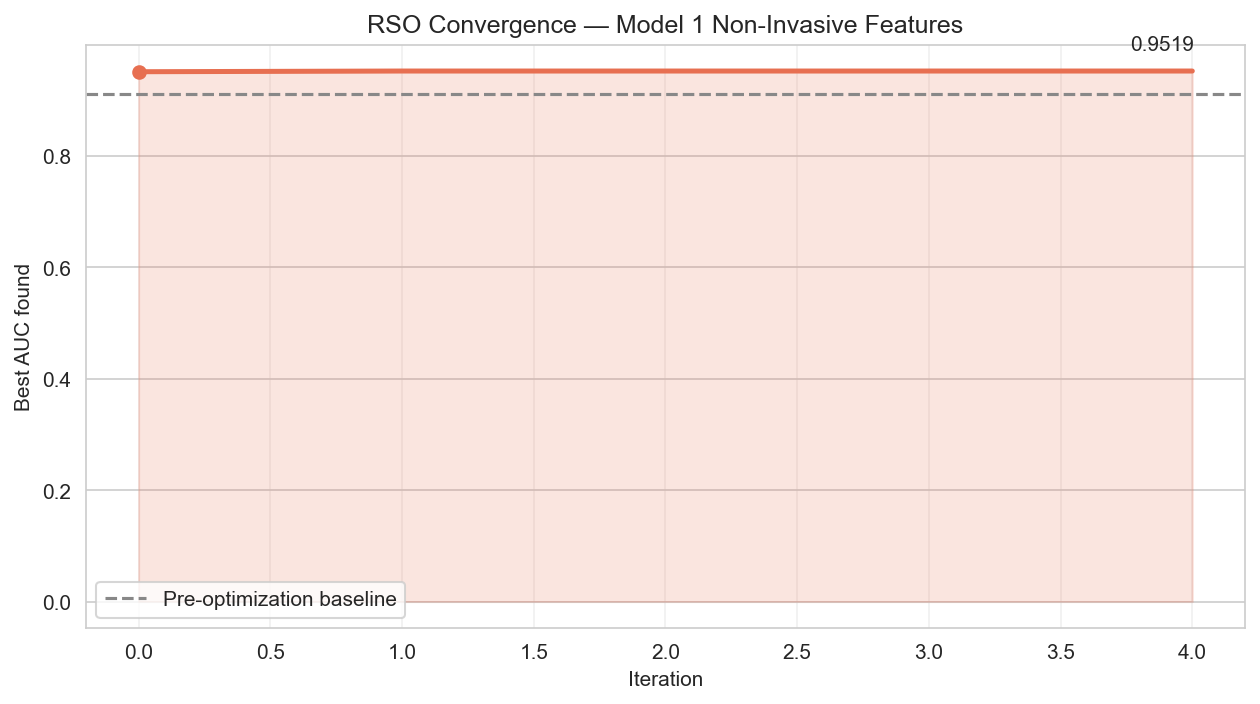

In [28]:
# Plotting the RSO convergence curve is showing how the best Model 1 score changed under the rat-swarm update rule.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(rso_m1_conv_df['iteration'], rso_m1_conv_df['best_auc'], color=COLORS['rso'], lw=2.4, marker='o', markevery=5)
ax.fill_between(rso_m1_conv_df['iteration'], rso_m1_conv_df['best_auc'], color=COLORS['rso'], alpha=0.18)
ax.axhline(baseline_stack_m1_auc, color=COLORS['baseline'], linestyle='--', lw=1.5, label='Pre-optimization baseline')
ax.annotate(f"{rso_m1_conv_df['best_auc'].iloc[-1]:.4f}", xy=(rso_m1_conv_df['iteration'].iloc[-1], rso_m1_conv_df['best_auc'].iloc[-1]), xytext=(-30, 10), textcoords='offset points')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('RSO Convergence — Model 1 Non-Invasive Features')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/07_model1_rso_convergence.png', bbox_inches='tight')
plt.show()


### Simple Reading of the RSO Convergence Plot
This chart is showing how the best Model 1 AUC changed under RSO. If the curve rises early and then tightens, it matches the idea that RSO explores more at the start and becomes more focused later. This matters because the shape of the curve helps explain why one optimizer may beat another, not just whether it wins in the end.


In [29]:
# Running CSO on Model 1 is starting the third optimizer search on the non-invasive stack.
print('Running Cat Swarm Optimization on Model 1 — Non-Invasive Features')
print('=' * 60)
np.random.seed(RANDOM_STATE)
start_time = time.time()
cso_m1_params, cso_m1_auc, cso_m1_history = cat_swarm_optimization(
    obj_func=lambda p: objective(p, X1_train, y1_train, stack_family=stack_family_m1),
    lb=LOWER_BOUNDS,
    ub=UPPER_BOUNDS,
    n_pop=POP_SIZE,
    n_iter=N_EPOCHS,
    target_auc=target_auc_m1,
    verbose=True
)
cso_m1_time = time.time() - start_time
np.save('models/model1_cso_convergence.npy', cso_m1_history)
print()
print('CSO Model 1 complete.')
print(f'Best AUC found: {cso_m1_auc:.4f}')
print(f'Time taken    : {cso_m1_time:.1f} seconds')
print()
print('Best hyperparameters found by CSO for Model 1:')
for key, value in decode_params(cso_m1_params).items():
    print(f'  {key:25s}: {value}')


Running Cat Swarm Optimization on Model 1 — Non-Invasive Features
  CSO early stopping: target AUC reached at iteration 4.

CSO Model 1 complete.
Best AUC found: 0.9548
Time taken    : 316.4 seconds

Best hyperparameters found by CSO for Model 1:
  rf_n_estimators          : 479
  rf_max_depth             : 20
  rf_min_samples_split     : 2
  xgb_n_estimators         : 400
  xgb_learning_rate        : 0.01
  xgb_max_depth            : 2
  xgb_subsample            : 1.0
  meta_C                   : 10.0
  meta_n_estimators        : 300


In [30]:
# Printing the CSO convergence table is showing the exact values behind the next curve.
cso_m1_conv_df = pd.DataFrame({'iteration': np.arange(len(cso_m1_history)), 'best_auc': -cso_m1_history})
cso_m1_conv_df['improvement'] = cso_m1_conv_df['best_auc'].diff().fillna(0.0)
print(cso_m1_conv_df.to_string(index=False))


 iteration  best_auc  improvement
         0  0.950612     0.000000
         1  0.952498     0.001886
         2  0.953103     0.000605
         3  0.954752     0.001650
         4  0.954752     0.000000


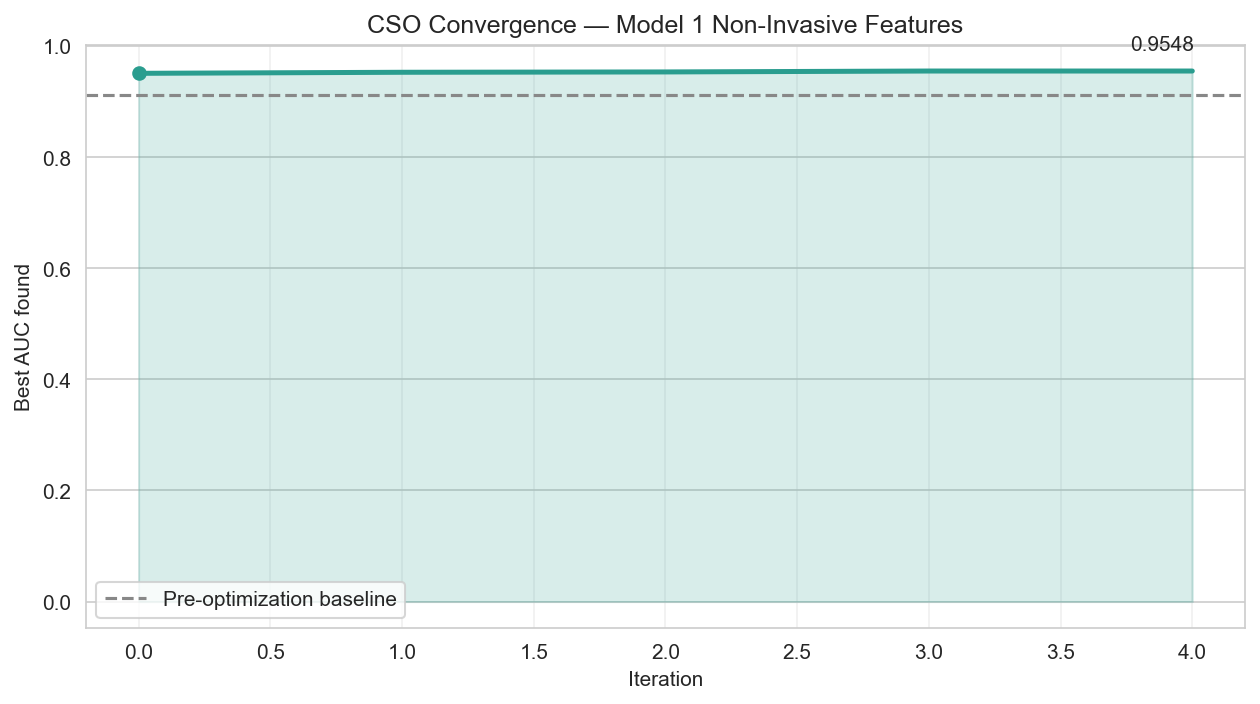

In [31]:
# Plotting the CSO convergence curve is showing how the best Model 1 score changed under tracing and seeking updates.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(cso_m1_conv_df['iteration'], cso_m1_conv_df['best_auc'], color=COLORS['cso'], lw=2.4, marker='o', markevery=5)
ax.fill_between(cso_m1_conv_df['iteration'], cso_m1_conv_df['best_auc'], color=COLORS['cso'], alpha=0.18)
ax.axhline(baseline_stack_m1_auc, color=COLORS['baseline'], linestyle='--', lw=1.5, label='Pre-optimization baseline')
ax.annotate(f"{cso_m1_conv_df['best_auc'].iloc[-1]:.4f}", xy=(cso_m1_conv_df['iteration'].iloc[-1], cso_m1_conv_df['best_auc'].iloc[-1]), xytext=(-30, 10), textcoords='offset points')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('CSO Convergence — Model 1 Non-Invasive Features')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/08_model1_cso_convergence.png', bbox_inches='tight')
plt.show()


### Simple Reading of the CSO Convergence Plot
This chart is showing how the best Model 1 AUC changes under CSO. A smooth curve usually means the velocity memory is keeping the search stable. This matters because some optimizers improve quickly but fluctuate, while others improve more steadily.


In [32]:
# Printing the Model 1 convergence comparison table is showing the exact values behind the next multi-optimizer chart.
m1_convergence_compare = pd.DataFrame({
    'iteration': np.arange(len(wao_m1_history)),
    'WaO_AUC': -wao_m1_history,
    'RSO_AUC': -rso_m1_history,
    'CSO_AUC': -cso_m1_history
})
print(m1_convergence_compare[m1_convergence_compare['iteration'] % 5 == 0].to_string(index=False))


 iteration  WaO_AUC  RSO_AUC  CSO_AUC
         0 0.950612 0.950612 0.950612


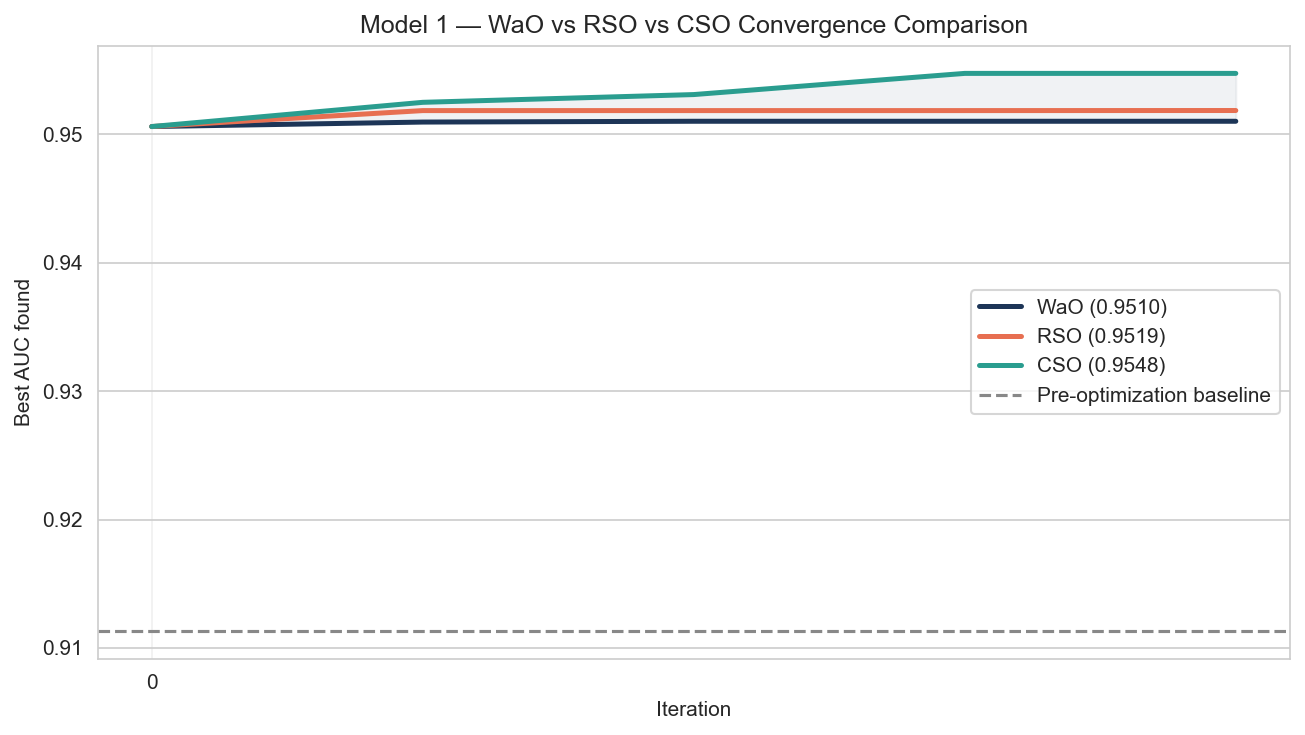

In [33]:
# Plotting the combined Model 1 convergence chart is comparing how the three optimizers search over time.
fig, ax = plt.subplots(figsize=(8.8, 5.0))
ax.plot(m1_convergence_compare['iteration'], m1_convergence_compare['WaO_AUC'], color=COLORS['wao'], lw=2.4, label=f"WaO ({m1_convergence_compare['WaO_AUC'].iloc[-1]:.4f})")
ax.plot(m1_convergence_compare['iteration'], m1_convergence_compare['RSO_AUC'], color=COLORS['rso'], lw=2.4, label=f"RSO ({m1_convergence_compare['RSO_AUC'].iloc[-1]:.4f})")
ax.plot(m1_convergence_compare['iteration'], m1_convergence_compare['CSO_AUC'], color=COLORS['cso'], lw=2.4, label=f"CSO ({m1_convergence_compare['CSO_AUC'].iloc[-1]:.4f})")
ax.axhline(baseline_stack_m1_auc, color=COLORS['baseline'], linestyle='--', lw=1.5, label='Pre-optimization baseline')
upper = m1_convergence_compare[['WaO_AUC', 'RSO_AUC', 'CSO_AUC']].max(axis=1)
lower = m1_convergence_compare[['WaO_AUC', 'RSO_AUC', 'CSO_AUC']].min(axis=1)
ax.fill_between(m1_convergence_compare['iteration'], lower, upper, color='#B0B7C3', alpha=0.18)
ax.set_xticks(np.arange(0, len(m1_convergence_compare), 10))
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('Model 1 — WaO vs RSO vs CSO Convergence Comparison')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/09_model1_all_convergence_comparison.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 1 Convergence Comparison
This chart is showing all three search paths together. The highest line at the end gives the best final optimizer. The line that reaches a strong level earlier is the faster searcher. This matters because the thesis is comparing not only final performance, but also how efficiently each optimizer finds a good answer.


In [34]:
# Summarizing the Model 1 optimizer results is identifying the current best optimizer before final test-set rebuilding.
m1_opt_df = pd.DataFrame({
    'Optimizer': ['WaO', 'RSO', 'CSO'],
    'Best AUC': [wao_m1_auc, rso_m1_auc, cso_m1_auc],
    'Time (sec)': [wao_m1_time, rso_m1_time, cso_m1_time]
}).sort_values('Best AUC', ascending=False).reset_index(drop=True)
print('Model 1 — Optimizer Comparison:')
print(m1_opt_df.to_string(index=False))
print()
best_m1_optimizer = m1_opt_df.iloc[0]['Optimizer']
m1_optimizer_results = {'WaO': {'auc': wao_m1_auc, 'params': wao_m1_params, 'time': wao_m1_time}, 'RSO': {'auc': rso_m1_auc, 'params': rso_m1_params, 'time': rso_m1_time}, 'CSO': {'auc': cso_m1_auc, 'params': cso_m1_params, 'time': cso_m1_time}}
best_m1_params = m1_optimizer_results[best_m1_optimizer]['params']
best_m1_auc = m1_optimizer_results[best_m1_optimizer]['auc']
print(f'Best optimizer for Model 1: {best_m1_optimizer} (AUC = {best_m1_auc:.4f})')


Model 1 — Optimizer Comparison:
Optimizer  Best AUC  Time (sec)
      CSO  0.954752  316.435330
      RSO  0.951860  206.042850
      WaO  0.951023  411.491349

Best optimizer for Model 1: CSO (AUC = 0.9548)


In [35]:
# Building and saving the three optimized Model 1 ensembles is turning the search results into full testable model artifacts.
ensemble_wao_m1, results_wao_m1 = build_optimized_ensemble(wao_m1_params, X1_train, y1_train, X1_test, y1_test, stack_family_m1, 'Model 1 - WaO Optimized', MODEL1_FEATURES)
ensemble_rso_m1, results_rso_m1 = build_optimized_ensemble(rso_m1_params, X1_train, y1_train, X1_test, y1_test, stack_family_m1, 'Model 1 - RSO Optimized', MODEL1_FEATURES)
ensemble_cso_m1, results_cso_m1 = build_optimized_ensemble(cso_m1_params, X1_train, y1_train, X1_test, y1_test, stack_family_m1, 'Model 1 - CSO Optimized', MODEL1_FEATURES)
joblib.dump(ensemble_wao_m1, 'models/model1_wao_optimized.pkl')
joblib.dump(ensemble_rso_m1, 'models/model1_rso_optimized.pkl')
joblib.dump(ensemble_cso_m1, 'models/model1_cso_optimized.pkl')
print('Model 1 optimized ensembles saved.')
print(pd.DataFrame([results_wao_m1, results_rso_m1, results_cso_m1]).round(4).to_string(index=False))


Model 1 optimized ensembles saved.
                  model  accuracy  precision  recall     f1    auc
Model 1 - WaO Optimized    0.8716     0.8235  0.7778 0.8000 0.8988
Model 1 - RSO Optimized    0.8624     0.8182  0.7500 0.7826 0.9102
Model 1 - CSO Optimized    0.8624     0.8387  0.7222 0.7761 0.9132


In [36]:
# Saving the best final optimized Model 1 artifact is fixing the strongest Model 1 optimizer result for later notebooks.
if best_m1_optimizer == 'WaO':
    best_m1_ensemble = ensemble_wao_m1
elif best_m1_optimizer == 'RSO':
    best_m1_ensemble = ensemble_rso_m1
else:
    best_m1_ensemble = ensemble_cso_m1
joblib.dump(best_m1_ensemble, 'models/model1_final_optimized.pkl')
with open('models/model1_best_params.json', 'w', encoding='utf-8') as f:
    json.dump({'optimizer': best_m1_optimizer, 'stack_family': stack_family_m1, 'auc': float(best_m1_auc), 'params': {k: float(v) for k, v in decode_params(best_m1_params).items()}}, f, indent=2)
print(f'model1_final_optimized.pkl saved — optimizer: {best_m1_optimizer}')
print('model1_best_params.json saved')


model1_final_optimized.pkl saved — optimizer: CSO
model1_best_params.json saved


In [37]:
# Printing the Model 1 optimizer performance table is showing the exact metric values behind the next comparison chart.
m1_opt_results_df = pd.DataFrame([{'Optimizer': 'WaO', **results_wao_m1}, {'Optimizer': 'RSO', **results_rso_m1}, {'Optimizer': 'CSO', **results_cso_m1}]).round(4)
print(m1_opt_results_df.to_string(index=False))


Optimizer                   model  accuracy  precision  recall     f1    auc
      WaO Model 1 - WaO Optimized    0.8716     0.8235  0.7778 0.8000 0.8988
      RSO Model 1 - RSO Optimized    0.8624     0.8182  0.7500 0.7826 0.9102
      CSO Model 1 - CSO Optimized    0.8624     0.8387  0.7222 0.7761 0.9132


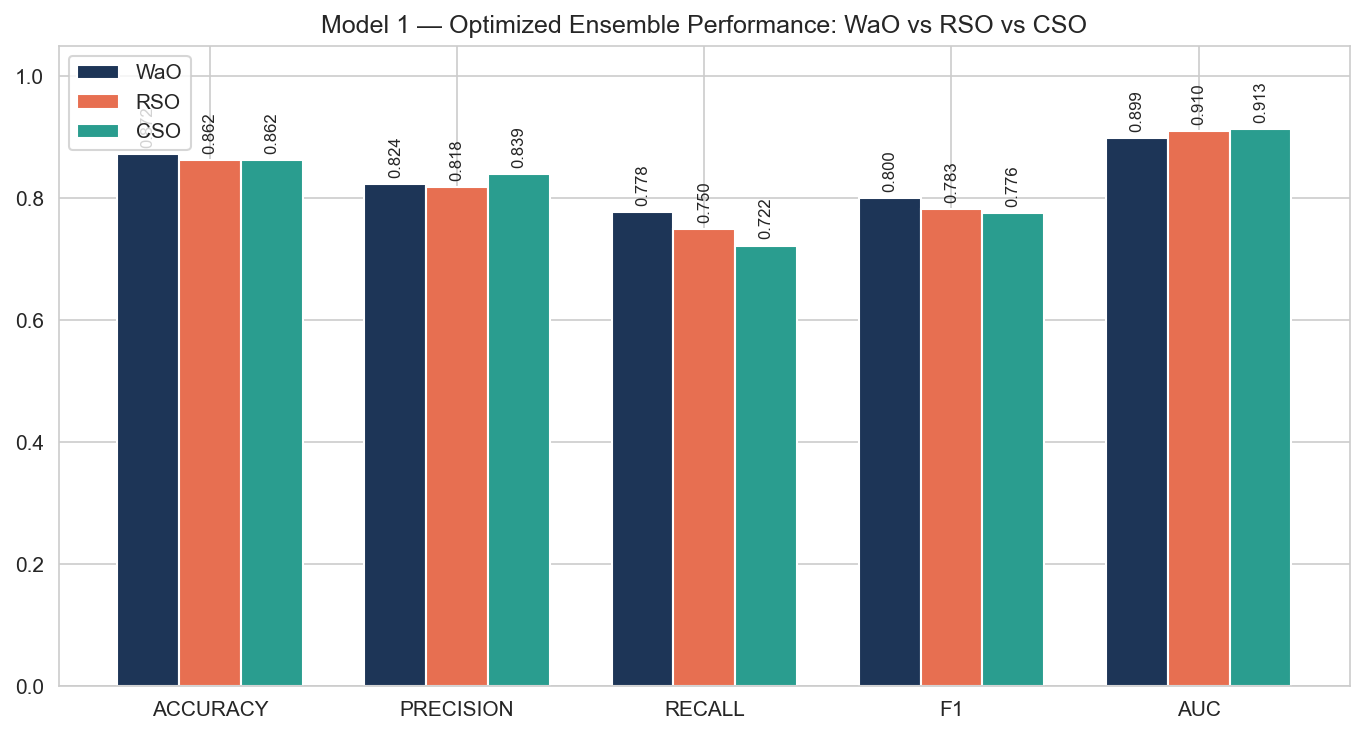

In [38]:
# Plotting the Model 1 optimizer comparison is showing how the three optimizers compare on the final test metrics.
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(9.2, 5.0))
for idx, (optimizer, color) in enumerate([('WaO', COLORS['wao']), ('RSO', COLORS['rso']), ('CSO', COLORS['cso'])]):
    values = m1_opt_results_df.loc[m1_opt_results_df['Optimizer'] == optimizer, metrics].iloc[0].values
    bars = ax.bar(x + (idx - 1) * width, values, width=width, label=optimizer, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylim(0, 1.05)
ax.set_title('Model 1 — Optimized Ensemble Performance: WaO vs RSO vs CSO')
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/14_model1_optimizer_performance_comparison.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 1 Optimizer Comparison
This chart is showing which optimizer gave the best final test performance after tuning the non-invasive stack. The best optimizer is the one that keeps AUC high while also keeping recall strong. This matters because a screening model must not only score well overall, but also catch as many true PCOS cases as possible.


## Section 6 — Running Optimization on Model 2

### Model 2 Optimization
This section is repeating the same search process on the invasive benchmark feature set. The difference is that Model 2 is built from hormonal and ultrasound features, so the optimizer is now searching a feature space that is richer and often more clinically specific. The same three optimizers are being used so the comparison stays fair. The reduced population, shorter run length, and early stopping rule are also being kept here so both model sets are optimized under the same practical runtime conditions.


In [39]:
# Running WaO on Model 2 is starting the first optimizer search on the invasive benchmark stack.
print('Running Walrus Optimization on Model 2 — Invasive Benchmark Features')
print('=' * 60)
np.random.seed(RANDOM_STATE)
target_auc_m2 = baseline_stack_m2_auc + TARGET_GAIN
print(f'Target AUC for early stop: {target_auc_m2:.4f}')
start_time = time.time()
wao_m2_params, wao_m2_auc, wao_m2_history = walrus_optimization(
    obj_func=lambda p: objective(p, X2_train, y2_train, stack_family=stack_family_m2),
    lb=LOWER_BOUNDS,
    ub=UPPER_BOUNDS,
    n_pop=POP_SIZE,
    n_iter=N_EPOCHS,
    target_auc=target_auc_m2,
    verbose=True
)
wao_m2_time = time.time() - start_time
np.save('models/model2_wao_convergence.npy', wao_m2_history)
print()
print('WaO Model 2 complete.')
print(f'Best AUC found: {wao_m2_auc:.4f}')
print(f'Time taken    : {wao_m2_time:.1f} seconds')
print()
print('Best hyperparameters found by WaO for Model 2:')
for key, value in decode_params(wao_m2_params).items():
    print(f'  {key:25s}: {value}')


Running Walrus Optimization on Model 2 — Invasive Benchmark Features
Target AUC for early stop: 0.9057
  WaO early stopping: target AUC reached at iteration 4.

WaO Model 2 complete.
Best AUC found: 0.9420
Time taken    : 387.8 seconds

Best hyperparameters found by WaO for Model 2:
  rf_n_estimators          : 212
  rf_max_depth             : 11
  rf_min_samples_split     : 4
  xgb_n_estimators         : 190
  xgb_learning_rate        : 0.012947624828424056
  xgb_max_depth            : 2
  xgb_subsample            : 0.5055442067139203
  meta_C                   : 4.5008728847452355
  meta_n_estimators        : 179


In [40]:
# Printing the WaO convergence table for Model 2 is showing the exact values behind the next curve.
wao_m2_conv_df = pd.DataFrame({'iteration': np.arange(len(wao_m2_history)), 'best_auc': -wao_m2_history})
wao_m2_conv_df['improvement'] = wao_m2_conv_df['best_auc'].diff().fillna(0.0)
print(wao_m2_conv_df.to_string(index=False))

 iteration  best_auc  improvement
         0  0.941596     0.000000
         1  0.941989     0.000393
         2  0.941989     0.000000
         3  0.941989     0.000000
         4  0.941989     0.000000


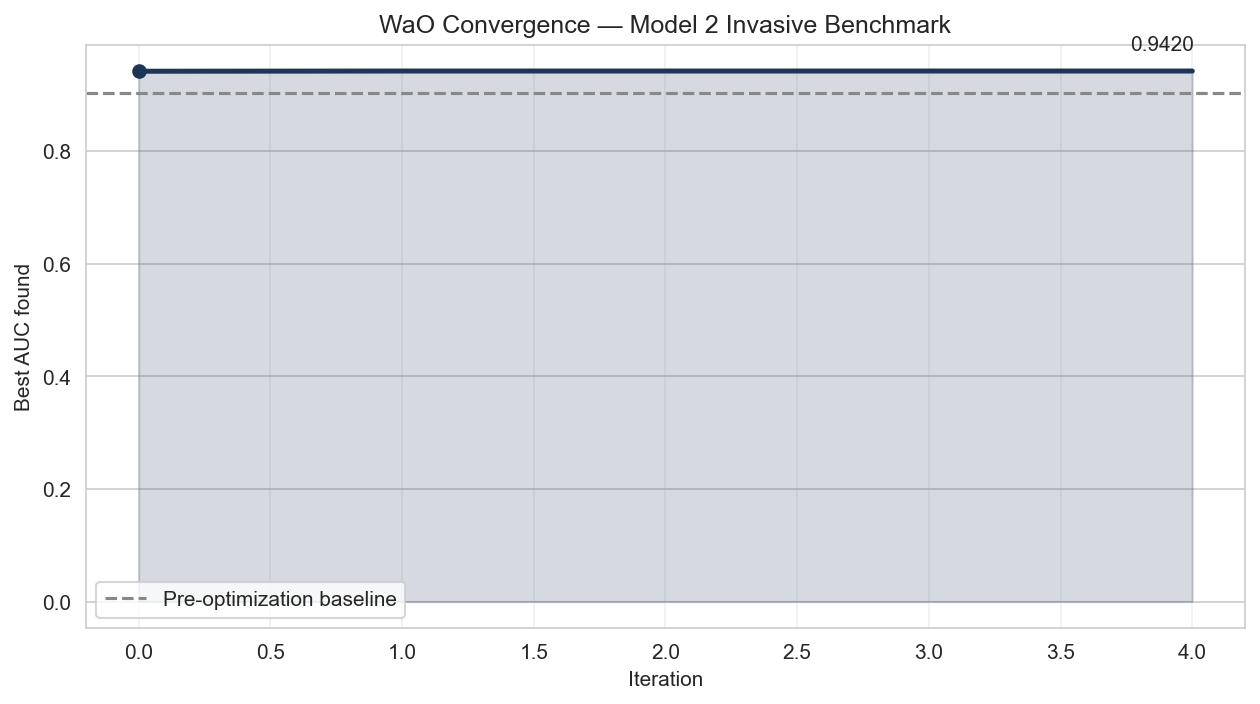

In [41]:
# Plotting the WaO Model 2 curve is showing how the invasive benchmark score improves under the walrus search rule.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(wao_m2_conv_df['iteration'], wao_m2_conv_df['best_auc'], color=COLORS['wao'], lw=2.4, marker='o', markevery=5)
ax.fill_between(wao_m2_conv_df['iteration'], wao_m2_conv_df['best_auc'], color=COLORS['wao'], alpha=0.18)
ax.axhline(baseline_stack_m2_auc, color=COLORS['baseline'], linestyle='--', lw=1.5, label='Pre-optimization baseline')
ax.annotate(f"{wao_m2_conv_df['best_auc'].iloc[-1]:.4f}", xy=(wao_m2_conv_df['iteration'].iloc[-1], wao_m2_conv_df['best_auc'].iloc[-1]), xytext=(-30, 10), textcoords='offset points')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('WaO Convergence — Model 2 Invasive Benchmark')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/10_model2_wao_convergence.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 2 WaO Plot
This chart is showing how WaO improves the invasive benchmark stack over time. If the curve settles at a higher level than the stacking baseline, it means the optimizer is finding better hyperparameter settings than the default stack used before.


In [42]:
# Running RSO on Model 2 is starting the second optimizer search on the invasive benchmark stack.
print('Running Rat Swarm Optimization on Model 2 — Invasive Benchmark Features')
print('=' * 60)
np.random.seed(RANDOM_STATE)
start_time = time.time()
rso_m2_params, rso_m2_auc, rso_m2_history = rat_swarm_optimization(
    obj_func=lambda p: objective(p, X2_train, y2_train, stack_family=stack_family_m2),
    lb=LOWER_BOUNDS,
    ub=UPPER_BOUNDS,
    n_pop=POP_SIZE,
    n_iter=N_EPOCHS,
    target_auc=target_auc_m2,
    verbose=True
)
rso_m2_time = time.time() - start_time
np.save('models/model2_rso_convergence.npy', rso_m2_history)
print()
print('RSO Model 2 complete.')
print(f'Best AUC found: {rso_m2_auc:.4f}')
print(f'Time taken    : {rso_m2_time:.1f} seconds')
print()
print('Best hyperparameters found by RSO for Model 2:')
for key, value in decode_params(rso_m2_params).items():
    print(f'  {key:25s}: {value}')


Running Rat Swarm Optimization on Model 2 — Invasive Benchmark Features
  RSO early stopping: target AUC reached at iteration 4.

RSO Model 2 complete.
Best AUC found: 0.9421
Time taken    : 229.7 seconds

Best hyperparameters found by RSO for Model 2:
  rf_n_estimators          : 282
  rf_max_depth             : 12
  rf_min_samples_split     : 4
  xgb_n_estimators         : 400
  xgb_learning_rate        : 0.07506141677114628
  xgb_max_depth            : 3
  xgb_subsample            : 0.9904882049756158
  meta_C                   : 9.221409913649332
  meta_n_estimators        : 192


In [43]:
# Printing the RSO convergence table for Model 2 is showing the exact values behind the next curve.
rso_m2_conv_df = pd.DataFrame({'iteration': np.arange(len(rso_m2_history)), 'best_auc': -rso_m2_history})
rso_m2_conv_df['improvement'] = rso_m2_conv_df['best_auc'].diff().fillna(0.0)
print(rso_m2_conv_df.to_string(index=False))

 iteration  best_auc  improvement
         0  0.941596     0.000000
         1  0.941616     0.000020
         2  0.941616     0.000000
         3  0.942144     0.000528
         4  0.942144     0.000000


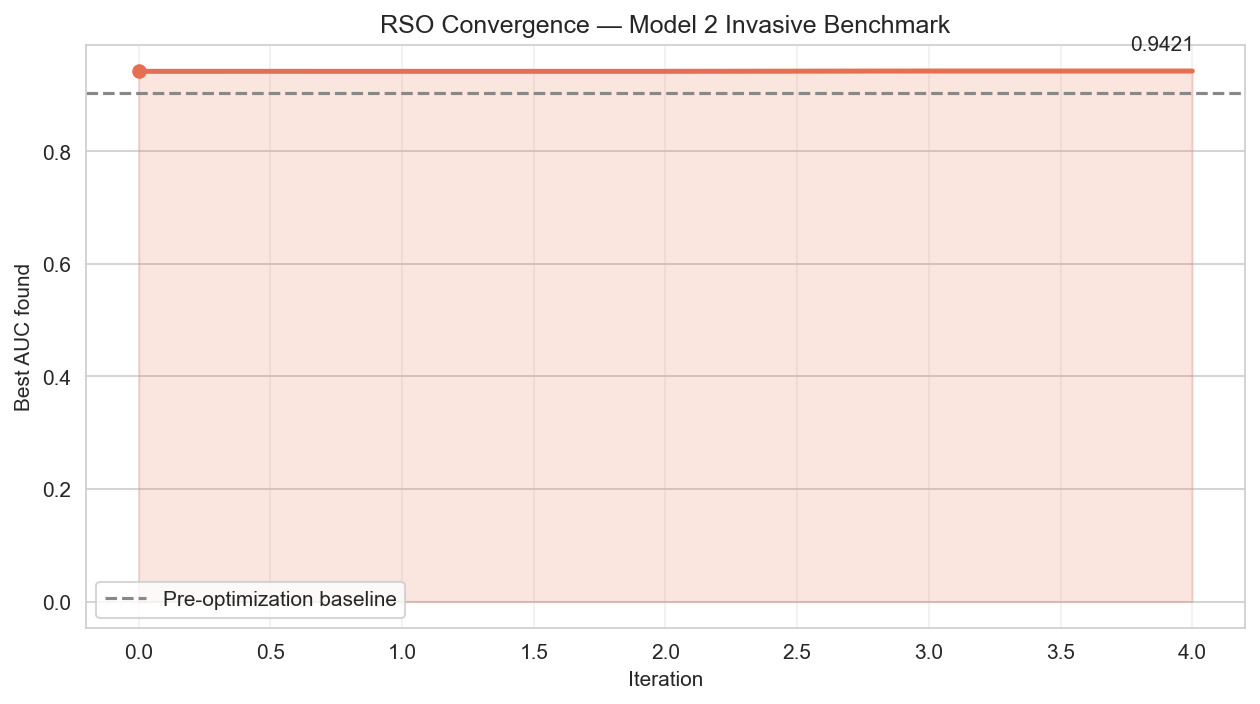

In [44]:
# Plotting the RSO Model 2 curve is showing how the invasive benchmark score changes under the rat-swarm rule.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(rso_m2_conv_df['iteration'], rso_m2_conv_df['best_auc'], color=COLORS['rso'], lw=2.4, marker='o', markevery=5)
ax.fill_between(rso_m2_conv_df['iteration'], rso_m2_conv_df['best_auc'], color=COLORS['rso'], alpha=0.18)
ax.axhline(baseline_stack_m2_auc, color=COLORS['baseline'], linestyle='--', lw=1.5, label='Pre-optimization baseline')
ax.annotate(f"{rso_m2_conv_df['best_auc'].iloc[-1]:.4f}", xy=(rso_m2_conv_df['iteration'].iloc[-1], rso_m2_conv_df['best_auc'].iloc[-1]), xytext=(-30, 10), textcoords='offset points')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('RSO Convergence — Model 2 Invasive Benchmark')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/11_model2_rso_convergence.png', bbox_inches='tight')
plt.show()

### Simple Reading of the Model 2 RSO Plot
This chart is showing the RSO search path for the invasive benchmark. A good run is rising above the baseline and then flattening near a high AUC. This matters because a strong invasive benchmark tells us what the optimized upper reference looks like for the thesis.


In [45]:
# Running CSO on Model 2 is starting the third optimizer search on the invasive benchmark stack.
print('Running Cat Swarm Optimization on Model 2 - Invasive Benchmark Features')
print('=' * 60)
np.random.seed(RANDOM_STATE)
start_time = time.time()
cso_m2_params, cso_m2_auc, cso_m2_history = cat_swarm_optimization(
    obj_func=lambda p: objective(p, X2_train, y2_train, stack_family=stack_family_m2),
    lb=LOWER_BOUNDS,
    ub=UPPER_BOUNDS,
    n_pop=POP_SIZE,
    n_iter=N_EPOCHS,
    target_auc=target_auc_m2,
    verbose=True
)
cso_m2_time = time.time() - start_time
np.save('models/model2_cso_convergence.npy', cso_m2_history)
print()
print('CSO Model 2 complete.')
print(f'Best AUC found: {cso_m2_auc:.4f}')
print(f'Time taken    : {cso_m2_time:.1f} seconds')
print()
print('Best hyperparameters found by CSO for Model 2:')
for key, value in decode_params(cso_m2_params).items():
    print(f'  {key:25s}: {value}')

Running Cat Swarm Optimization on Model 2 - Invasive Benchmark Features
  CSO early stopping: target AUC reached at iteration 4.

CSO Model 2 complete.
Best AUC found: 0.9416
Time taken    : 345.3 seconds

Best hyperparameters found by CSO for Model 2:
  rf_n_estimators          : 281
  rf_max_depth             : 13
  rf_min_samples_split     : 3
  xgb_n_estimators         : 263
  xgb_learning_rate        : 0.059451995869314544
  xgb_max_depth            : 3
  xgb_subsample            : 0.9744427686266666
  meta_C                   : 9.656664010414849
  meta_n_estimators        : 252


In [46]:
# Printing the CSO convergence table for Model 2 is showing the exact values behind the next curve.
cso_m2_conv_df = pd.DataFrame({'iteration': np.arange(len(cso_m2_history)), 'best_auc': -cso_m2_history})
cso_m2_conv_df['improvement'] = cso_m2_conv_df['best_auc'].diff().fillna(0.0)
print(cso_m2_conv_df.to_string(index=False))


 iteration  best_auc  improvement
         0  0.941596          0.0
         1  0.941596          0.0
         2  0.941596          0.0
         3  0.941596          0.0
         4  0.941596          0.0


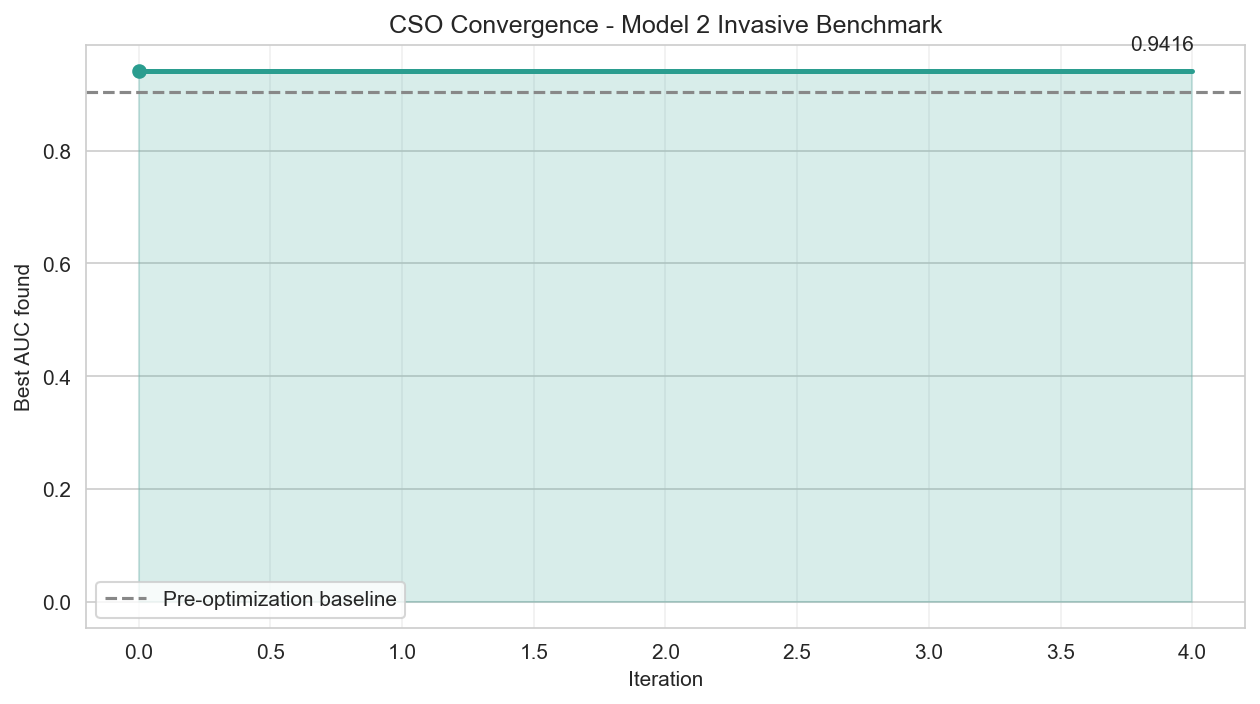

In [47]:
# Plotting the CSO Model 2 curve is showing how the invasive benchmark score changes under the cat-swarm rule.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(cso_m2_conv_df['iteration'], cso_m2_conv_df['best_auc'], color=COLORS['cso'], lw=2.4, marker='o', markevery=5)
ax.fill_between(cso_m2_conv_df['iteration'], cso_m2_conv_df['best_auc'], color=COLORS['cso'], alpha=0.18)
ax.axhline(baseline_stack_m2_auc, color=COLORS['baseline'], linestyle='--', lw=1.5, label='Pre-optimization baseline')
ax.annotate(f"{cso_m2_conv_df['best_auc'].iloc[-1]:.4f}", xy=(cso_m2_conv_df['iteration'].iloc[-1], cso_m2_conv_df['best_auc'].iloc[-1]), xytext=(-30, 10), textcoords='offset points')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('CSO Convergence - Model 2 Invasive Benchmark')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/12_model2_cso_convergence.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 2 CSO Plot
This chart is showing how CSO improves the invasive benchmark score over time. A smooth curve usually means the optimizer is making steady progress instead of jumping around too much. This matters because stable search is often easier to trust and explain.


In [48]:
# Printing the combined Model 2 convergence table is putting all three optimizer paths side by side for direct comparison.
m2_convergence_compare = pd.DataFrame({
    'iteration': np.arange(len(wao_m2_history)),
    'WaO_AUC': -wao_m2_history,
    'RSO_AUC': -rso_m2_history,
    'CSO_AUC': -cso_m2_history
})
print(m2_convergence_compare[m2_convergence_compare['iteration'] % 5 == 0].to_string(index=False))


 iteration  WaO_AUC  RSO_AUC  CSO_AUC
         0 0.941596 0.941596 0.941596


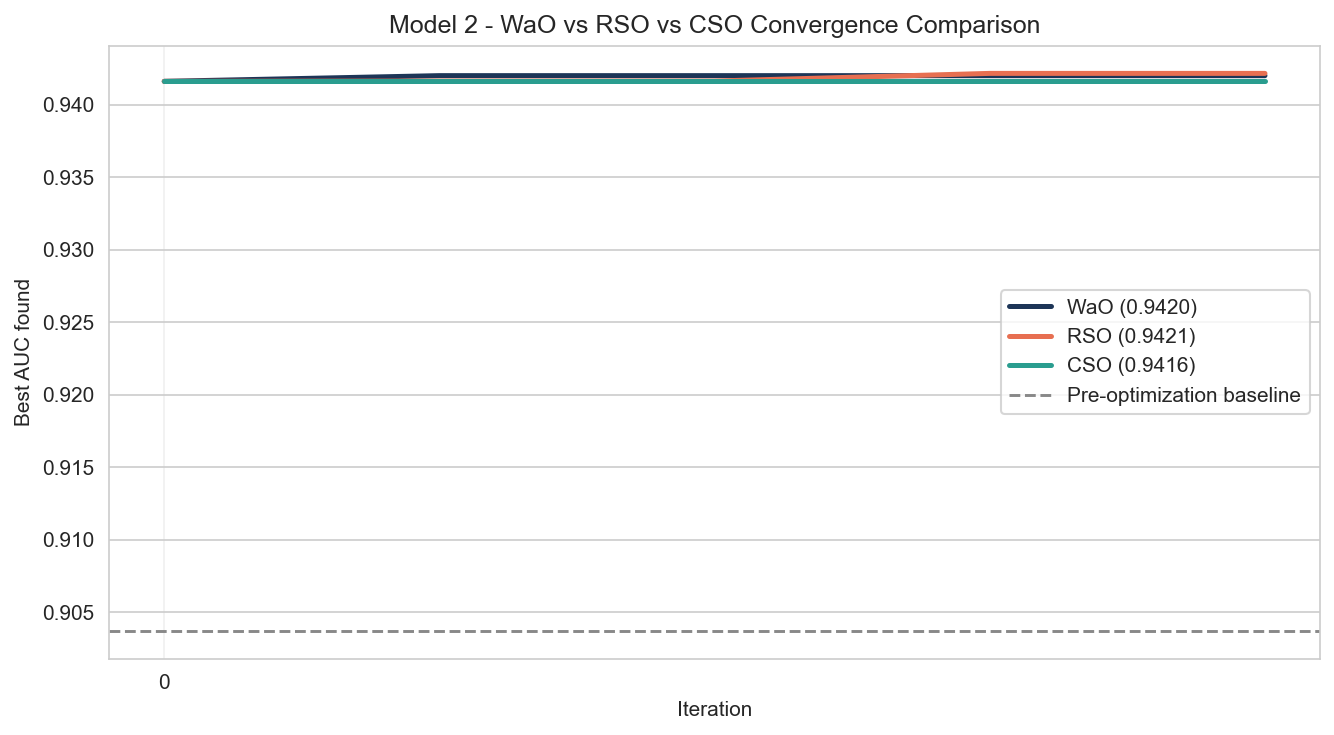

In [49]:
# Plotting the combined Model 2 convergence curves is showing which optimizer reaches the strongest invasive benchmark result most clearly.
fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(m2_convergence_compare['iteration'], m2_convergence_compare['WaO_AUC'], color=COLORS['wao'], lw=2.4, label=f"WaO ({m2_convergence_compare['WaO_AUC'].iloc[-1]:.4f})")
ax.plot(m2_convergence_compare['iteration'], m2_convergence_compare['RSO_AUC'], color=COLORS['rso'], lw=2.4, label=f"RSO ({m2_convergence_compare['RSO_AUC'].iloc[-1]:.4f})")
ax.plot(m2_convergence_compare['iteration'], m2_convergence_compare['CSO_AUC'], color=COLORS['cso'], lw=2.4, label=f"CSO ({m2_convergence_compare['CSO_AUC'].iloc[-1]:.4f})")
lower_band = np.minimum.reduce([m2_convergence_compare['WaO_AUC'], m2_convergence_compare['RSO_AUC'], m2_convergence_compare['CSO_AUC']])
upper_band = np.maximum.reduce([m2_convergence_compare['WaO_AUC'], m2_convergence_compare['RSO_AUC'], m2_convergence_compare['CSO_AUC']])
ax.fill_between(m2_convergence_compare['iteration'], lower_band, upper_band, color='#BBBBBB', alpha=0.12)
ax.axhline(baseline_stack_m2_auc, color=COLORS['baseline'], linestyle='--', lw=1.4, label='Pre-optimization baseline')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best AUC found')
ax.set_title('Model 2 - WaO vs RSO vs CSO Convergence Comparison')
ax.set_xticks(np.arange(0, len(m2_convergence_compare), 10))
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/13_model2_all_convergence_comparison.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 2 Convergence Comparison
This chart is showing all three optimizer paths on the invasive benchmark at once. The highest ending curve is the strongest optimizer for Model 2. This matters because the invasive model is the reference ceiling in this study, so we want to know which optimizer gets the most out of it.


In [50]:
# Identifying the best Model 2 optimizer is ranking the three search methods by their final AUC and runtime.
m2_optimizer_results = {'WaO': {'auc': wao_m2_auc, 'params': wao_m2_params, 'time': wao_m2_time}, 'RSO': {'auc': rso_m2_auc, 'params': rso_m2_params, 'time': rso_m2_time}, 'CSO': {'auc': cso_m2_auc, 'params': cso_m2_params, 'time': cso_m2_time}}
m2_opt_df = pd.DataFrame({
    'Optimizer': ['WaO', 'RSO', 'CSO'],
    'Best AUC': [wao_m2_auc, rso_m2_auc, cso_m2_auc],
    'Time (sec)': [wao_m2_time, rso_m2_time, cso_m2_time]
}).sort_values('Best AUC', ascending=False)
print(m2_opt_df.to_string(index=False))
print()
best_m2_optimizer = m2_opt_df.iloc[0]['Optimizer']
best_m2_params = m2_optimizer_results[best_m2_optimizer]['params']
best_m2_auc = m2_optimizer_results[best_m2_optimizer]['auc']
print(f'Best optimizer for Model 2: {best_m2_optimizer} (AUC = {best_m2_auc:.4f})')


Optimizer  Best AUC  Time (sec)
      RSO  0.942144  229.664467
      WaO  0.941989  387.764200
      CSO  0.941596  345.266450

Best optimizer for Model 2: RSO (AUC = 0.9421)


In [51]:
# Building and saving the three optimized Model 2 ensembles is turning the invasive search results into full testable model artifacts.
ensemble_wao_m2, results_wao_m2 = build_optimized_ensemble(wao_m2_params, X2_train, y2_train, X2_test, y2_test, stack_family_m2, 'Model 2 - WaO Optimized', MODEL2_FEATURES)
ensemble_rso_m2, results_rso_m2 = build_optimized_ensemble(rso_m2_params, X2_train, y2_train, X2_test, y2_test, stack_family_m2, 'Model 2 - RSO Optimized', MODEL2_FEATURES)
ensemble_cso_m2, results_cso_m2 = build_optimized_ensemble(cso_m2_params, X2_train, y2_train, X2_test, y2_test, stack_family_m2, 'Model 2 - CSO Optimized', MODEL2_FEATURES)
joblib.dump(ensemble_wao_m2, 'models/model2_wao_optimized.pkl')
joblib.dump(ensemble_rso_m2, 'models/model2_rso_optimized.pkl')
joblib.dump(ensemble_cso_m2, 'models/model2_cso_optimized.pkl')
print('Model 2 optimized ensembles saved.')
print(pd.DataFrame([results_wao_m2, results_rso_m2, results_cso_m2]).round(4).to_string(index=False))


Model 2 optimized ensembles saved.
                  model  accuracy  precision  recall     f1    auc
Model 2 - WaO Optimized    0.8716     0.8235  0.7778 0.8000 0.9068
Model 2 - RSO Optimized    0.8716     0.8235  0.7778 0.8000 0.9072
Model 2 - CSO Optimized    0.8716     0.8056  0.8056 0.8056 0.9064


In [52]:
# Saving the best final optimized Model 2 artifact is fixing the strongest Model 2 optimizer result for later notebooks.
if best_m2_optimizer == 'WaO':
    best_m2_ensemble = ensemble_wao_m2
elif best_m2_optimizer == 'RSO':
    best_m2_ensemble = ensemble_rso_m2
else:
    best_m2_ensemble = ensemble_cso_m2
joblib.dump(best_m2_ensemble, 'models/model2_final_optimized.pkl')
with open('models/model2_best_params.json', 'w', encoding='utf-8') as f:
    json.dump({'optimizer': best_m2_optimizer, 'stack_family': stack_family_m2, 'auc': float(best_m2_auc), 'params': {k: float(v) for k, v in decode_params(best_m2_params).items()}}, f, indent=2)
print(f'model2_final_optimized.pkl saved - optimizer: {best_m2_optimizer}')
print('model2_best_params.json saved')


model2_final_optimized.pkl saved - optimizer: RSO
model2_best_params.json saved


In [53]:
# Printing the Model 2 optimizer performance table is showing the exact metric values behind the next comparison chart.
m2_opt_results_df = pd.DataFrame([{'Optimizer': 'WaO', **results_wao_m2}, {'Optimizer': 'RSO', **results_rso_m2}, {'Optimizer': 'CSO', **results_cso_m2}]).round(4)
print(m2_opt_results_df.to_string(index=False))


Optimizer                   model  accuracy  precision  recall     f1    auc
      WaO Model 2 - WaO Optimized    0.8716     0.8235  0.7778 0.8000 0.9068
      RSO Model 2 - RSO Optimized    0.8716     0.8235  0.7778 0.8000 0.9072
      CSO Model 2 - CSO Optimized    0.8716     0.8056  0.8056 0.8056 0.9064


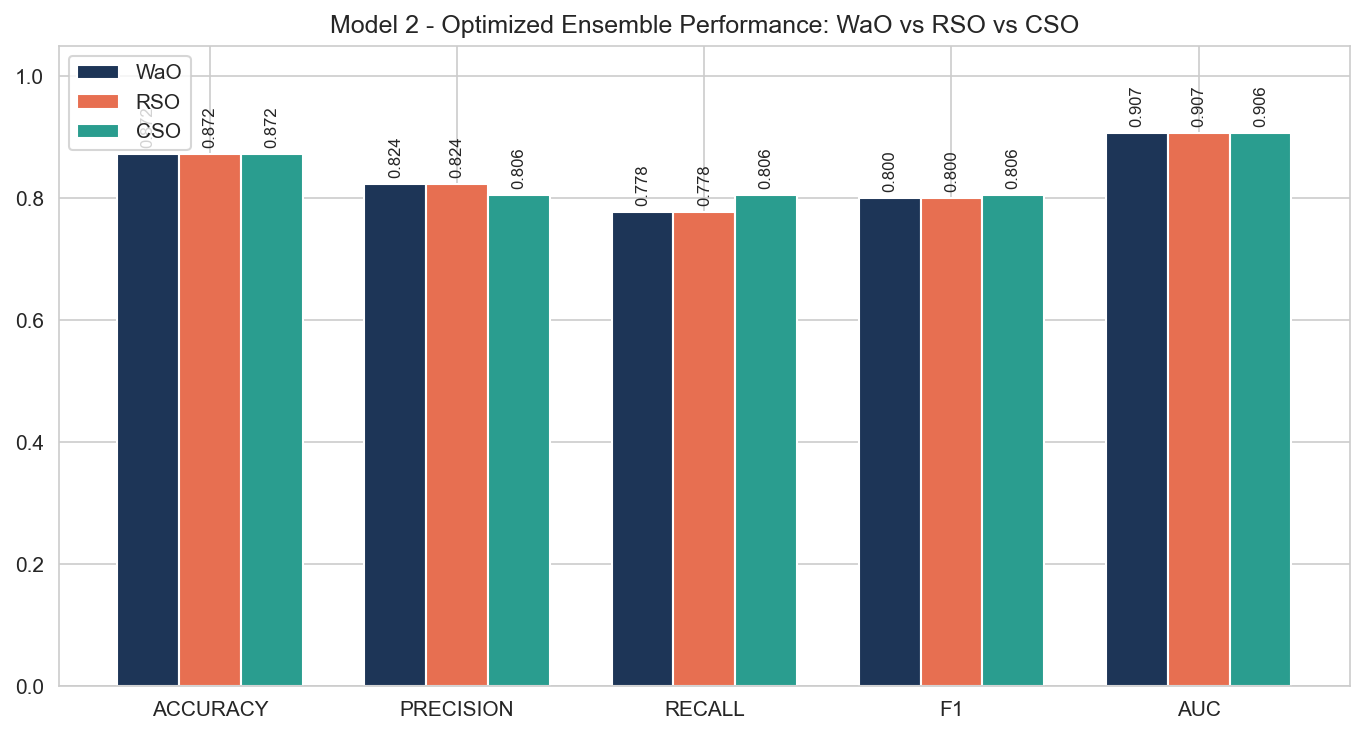

In [54]:
# Plotting the Model 2 optimizer comparison is showing how the three optimizers compare on the final invasive test metrics.
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(9.2, 5.0))
for idx, (optimizer, color) in enumerate([('WaO', COLORS['wao']), ('RSO', COLORS['rso']), ('CSO', COLORS['cso'])]):
    values = m2_opt_results_df.loc[m2_opt_results_df['Optimizer'] == optimizer, metrics].iloc[0].values
    bars = ax.bar(x + (idx - 1) * width, values, width=width, label=optimizer, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylim(0, 1.05)
ax.set_title('Model 2 - Optimized Ensemble Performance: WaO vs RSO vs CSO')
ax.legend()
plt.tight_layout()
plt.savefig('images/optimization/15_model2_optimizer_performance_comparison.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 2 Optimizer Comparison
This chart is showing which optimizer gave the strongest final invasive benchmark result. The best optimizer is the one that keeps AUC high while still holding useful recall. This matters because the invasive model is the comparison target for how much performance the non-invasive model can realistically reach.


## Section 7 - Final Comparison and Model Selection

This section is combining all results from the full modelling phase. It is bringing together the individual models, the stacking models, and the optimized models into one final comparison. This is the table that shows the full performance story from start to finish.


In [55]:
# Building the optimization results table is gathering the six optimizer outputs into one clean comparison table.
opt_results = pd.DataFrame([
    results_wao_m1, results_rso_m1, results_cso_m1,
    results_wao_m2, results_rso_m2, results_cso_m2
]).round(4)
opt_results['approach'] = 'Optimized'
opt_results['model_set'] = ['Model 1'] * 3 + ['Model 2'] * 3
opt_results['optimizer'] = ['WaO', 'RSO', 'CSO', 'WaO', 'RSO', 'CSO']
opt_results['algorithm'] = ['Optimized'] * len(opt_results)
print('OPTIMIZATION RESULTS TABLE')
print('=' * 70)
print(opt_results.to_string(index=False))


OPTIMIZATION RESULTS TABLE
                  model  accuracy  precision  recall     f1    auc  approach model_set optimizer algorithm
Model 1 - WaO Optimized    0.8716     0.8235  0.7778 0.8000 0.8988 Optimized   Model 1       WaO Optimized
Model 1 - RSO Optimized    0.8624     0.8182  0.7500 0.7826 0.9102 Optimized   Model 1       RSO Optimized
Model 1 - CSO Optimized    0.8624     0.8387  0.7222 0.7761 0.9132 Optimized   Model 1       CSO Optimized
Model 2 - WaO Optimized    0.8716     0.8235  0.7778 0.8000 0.9068 Optimized   Model 2       WaO Optimized
Model 2 - RSO Optimized    0.8716     0.8235  0.7778 0.8000 0.9072 Optimized   Model 2       RSO Optimized
Model 2 - CSO Optimized    0.8716     0.8056  0.8056 0.8056 0.9064 Optimized   Model 2       CSO Optimized


In [56]:
# Saving the optimization results table is preserving the six optimizer outcomes for later reporting.
opt_results.to_csv('cleaned_data/modelling_sets/optimization_results.csv', index=False)
print('optimization_results.csv saved.')


optimization_results.csv saved.


In [57]:
# Building and saving the final results table is combining all phases into one master thesis results file.
final_results = pd.concat([master_prev, opt_results], ignore_index=True).round(4)
final_results.to_csv('cleaned_data/modelling_sets/final_model_results.csv', index=False)

print('FINAL RESULTS TABLE')
print('=' * 80)
for phase in ['Individual', 'Stacking', 'Optimized']:
    phase_df = final_results[final_results['approach'] == phase]
    print(phase_df.to_string(index=False))
    print('-' * 80)
print('final_model_results.csv saved.')


FINAL RESULTS TABLE
        model  accuracy  precision  recall     f1    auc model_set algorithm   approach optimizer
 Model 1 - LR    0.8349     0.7368  0.7778 0.7568 0.8839   Model 1        LR Individual       NaN
 Model 1 - RF    0.8532     0.8125  0.7222 0.7647 0.9098   Model 1        RF Individual       NaN
Model 1 - XGB    0.8716     0.8438  0.7500 0.7941 0.9026   Model 1       XGB Individual       NaN
 Model 2 - LR    0.8349     0.7143  0.8333 0.7692 0.8988   Model 2        LR Individual       NaN
 Model 2 - RF    0.8349     0.7500  0.7500 0.7500 0.8955   Model 2        RF Individual       NaN
Model 2 - XGB    0.8624     0.8000  0.7778 0.7887 0.9037   Model 2       XGB Individual       NaN
--------------------------------------------------------------------------------
              model  accuracy  precision  recall     f1    auc model_set algorithm approach optimizer
 Model 1 - Stack-LR    0.8440     0.7879  0.7222 0.7536 0.9113   Model 1  Stack-LR Stacking       NaN
 Model 1 

In [58]:
# Printing the Model 1 progression table is showing the step-by-step improvement from individual to stacking to optimization.
model1_progress_df = pd.DataFrame({
    'Stage': ['Best Individual', 'Best Stacking', 'Best Optimized'],
    'AUC': [baseline_individual_m1_auc, baseline_stack_m1_auc, best_m1_auc]
})
model1_progress_df['Improvement_from_previous'] = model1_progress_df['AUC'].diff().fillna(0.0)
print(model1_progress_df.to_string(index=False))


          Stage      AUC  Improvement_from_previous
Best Individual 0.909800                   0.000000
  Best Stacking 0.911300                   0.001500
 Best Optimized 0.954752                   0.043452


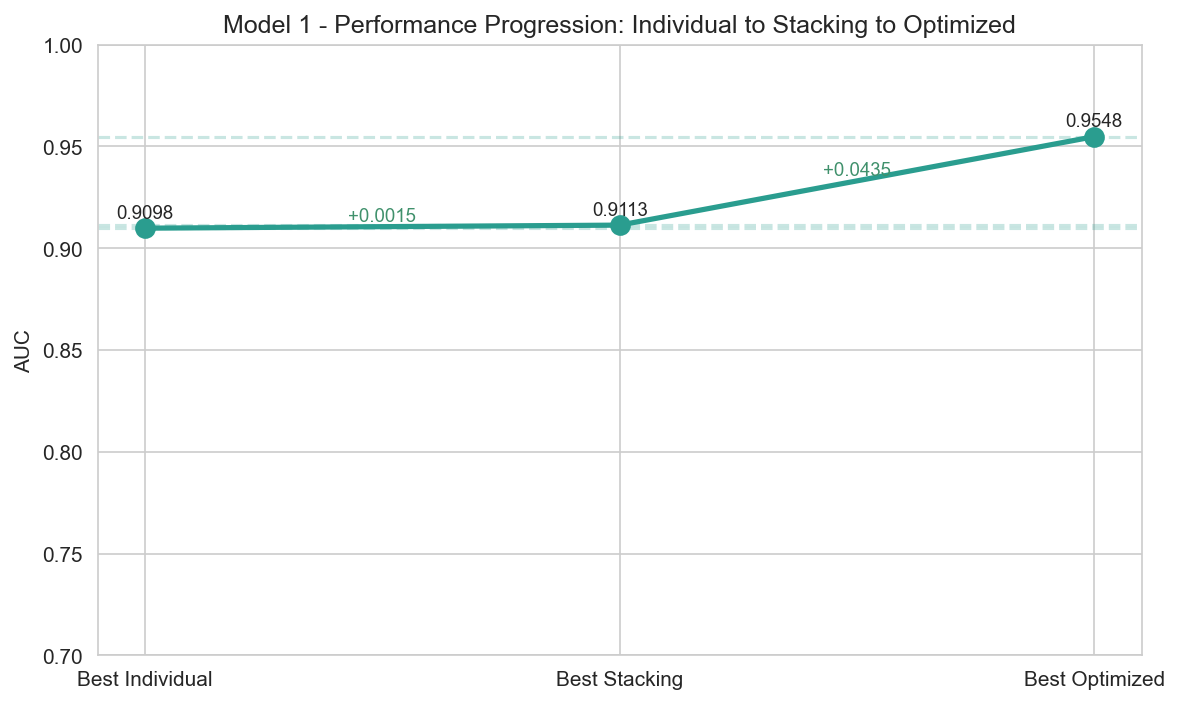

In [59]:
# Plotting the Model 1 progression chart is showing how performance changes across the three modelling phases.
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(model1_progress_df['Stage'], model1_progress_df['AUC'], marker='o', color=COLORS['model1'], lw=2.5)
ax.scatter(model1_progress_df['Stage'], model1_progress_df['AUC'], color=COLORS['model1'], s=80)
for idx, row in model1_progress_df.iterrows():
    ax.axhline(row['AUC'], color=COLORS['model1'], linestyle='--', alpha=0.25)
    ax.text(idx, row['AUC'] + 0.005, f"{row['AUC']:.4f}", ha='center', fontsize=9)
    if idx > 0:
        ax.text(idx - 0.5, (model1_progress_df.loc[idx - 1, 'AUC'] + row['AUC']) / 2 + 0.003, f"+{row['Improvement_from_previous']:.4f}", color=COLORS['improve'], ha='center', fontsize=9)
ax.set_ylim(0.70, 1.00)
ax.set_ylabel('AUC')
ax.set_title('Model 1 - Performance Progression: Individual to Stacking to Optimized')
plt.tight_layout()
plt.savefig('images/optimization/16_model1_optimized_vs_baseline_comparison.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 1 Progression Chart
This chart is showing how Model 1 improved step by step. The first point is the best single model, the second point is the best stack, and the third point is the best optimized stack. This matters because it tells us exactly how much each modelling phase added.


In [60]:
# Printing the Model 2 progression table is showing the step-by-step improvement from individual to stacking to optimization.
model2_progress_df = pd.DataFrame({
    'Stage': ['Best Individual', 'Best Stacking', 'Best Optimized'],
    'AUC': [baseline_individual_m2_auc, baseline_stack_m2_auc, best_m2_auc]
})
model2_progress_df['Improvement_from_previous'] = model2_progress_df['AUC'].diff().fillna(0.0)
print(model2_progress_df.to_string(index=False))


          Stage      AUC  Improvement_from_previous
Best Individual 0.903700                   0.000000
  Best Stacking 0.903700                   0.000000
 Best Optimized 0.942144                   0.038444


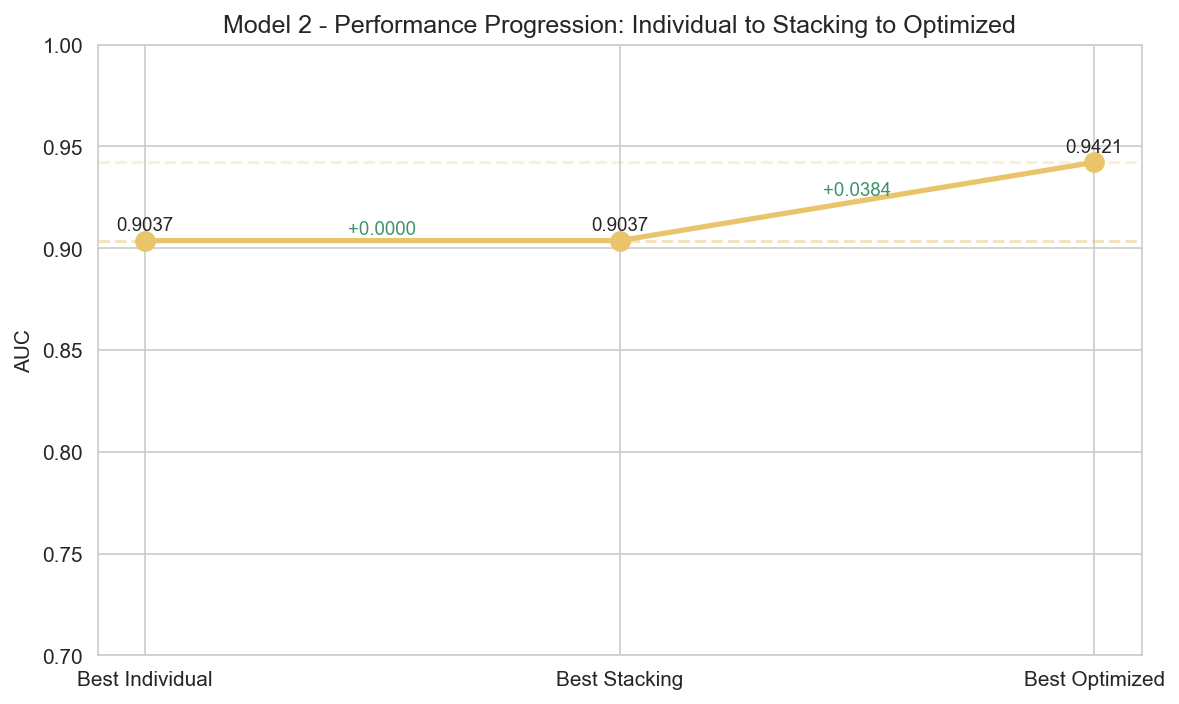

In [61]:
# Plotting the Model 2 progression chart is showing how performance changes across the three modelling phases for the invasive benchmark.
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(model2_progress_df['Stage'], model2_progress_df['AUC'], marker='o', color=COLORS['model2'], lw=2.5)
ax.scatter(model2_progress_df['Stage'], model2_progress_df['AUC'], color=COLORS['model2'], s=80)
for idx, row in model2_progress_df.iterrows():
    ax.axhline(row['AUC'], color=COLORS['model2'], linestyle='--', alpha=0.25)
    ax.text(idx, row['AUC'] + 0.005, f"{row['AUC']:.4f}", ha='center', fontsize=9)
    if idx > 0:
        ax.text(idx - 0.5, (model2_progress_df.loc[idx - 1, 'AUC'] + row['AUC']) / 2 + 0.003, f"+{row['Improvement_from_previous']:.4f}", color=COLORS['improve'], ha='center', fontsize=9)
ax.set_ylim(0.70, 1.00)
ax.set_ylabel('AUC')
ax.set_title('Model 2 - Performance Progression: Individual to Stacking to Optimized')
plt.tight_layout()
plt.savefig('images/optimization/17_model2_optimized_vs_baseline_comparison.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Model 2 Progression Chart
This chart is showing the same step-by-step progress for the invasive benchmark. It helps us see whether optimization gives a clear extra gain after stacking. This matters because the invasive model is the upper reference for the thesis comparison.


In [62]:
# Printing the final model summary table is showing the two thesis models that will be taken forward to explanation work.
best_model1_final_row = opt_results[opt_results['model_set'] == 'Model 1'].sort_values('auc', ascending=False).iloc[0]
best_model2_final_row = opt_results[opt_results['model_set'] == 'Model 2'].sort_values('auc', ascending=False).iloc[0]
final_gap_auc = best_model2_final_row['auc'] - best_model1_final_row['auc']
final_summary_df = pd.DataFrame({
    'Model Set': ['Model 1', 'Model 2'],
    'Best Optimizer': [best_model1_final_row['optimizer'], best_model2_final_row['optimizer']],
    'AUC': [best_model1_final_row['auc'], best_model2_final_row['auc']],
    'Recall': [best_model1_final_row['recall'], best_model2_final_row['recall']],
    'F1': [best_model1_final_row['f1'], best_model2_final_row['f1']]
}).round(4)
print(final_summary_df.to_string(index=False))
print()
print(f'Final AUC gap (Model 2 - Model 1): {final_gap_auc:.4f}')


Model Set Best Optimizer    AUC  Recall     F1
  Model 1            CSO 0.9132  0.7222 0.7761
  Model 2            RSO 0.9072  0.7778 0.8000

Final AUC gap (Model 2 - Model 1): -0.0060


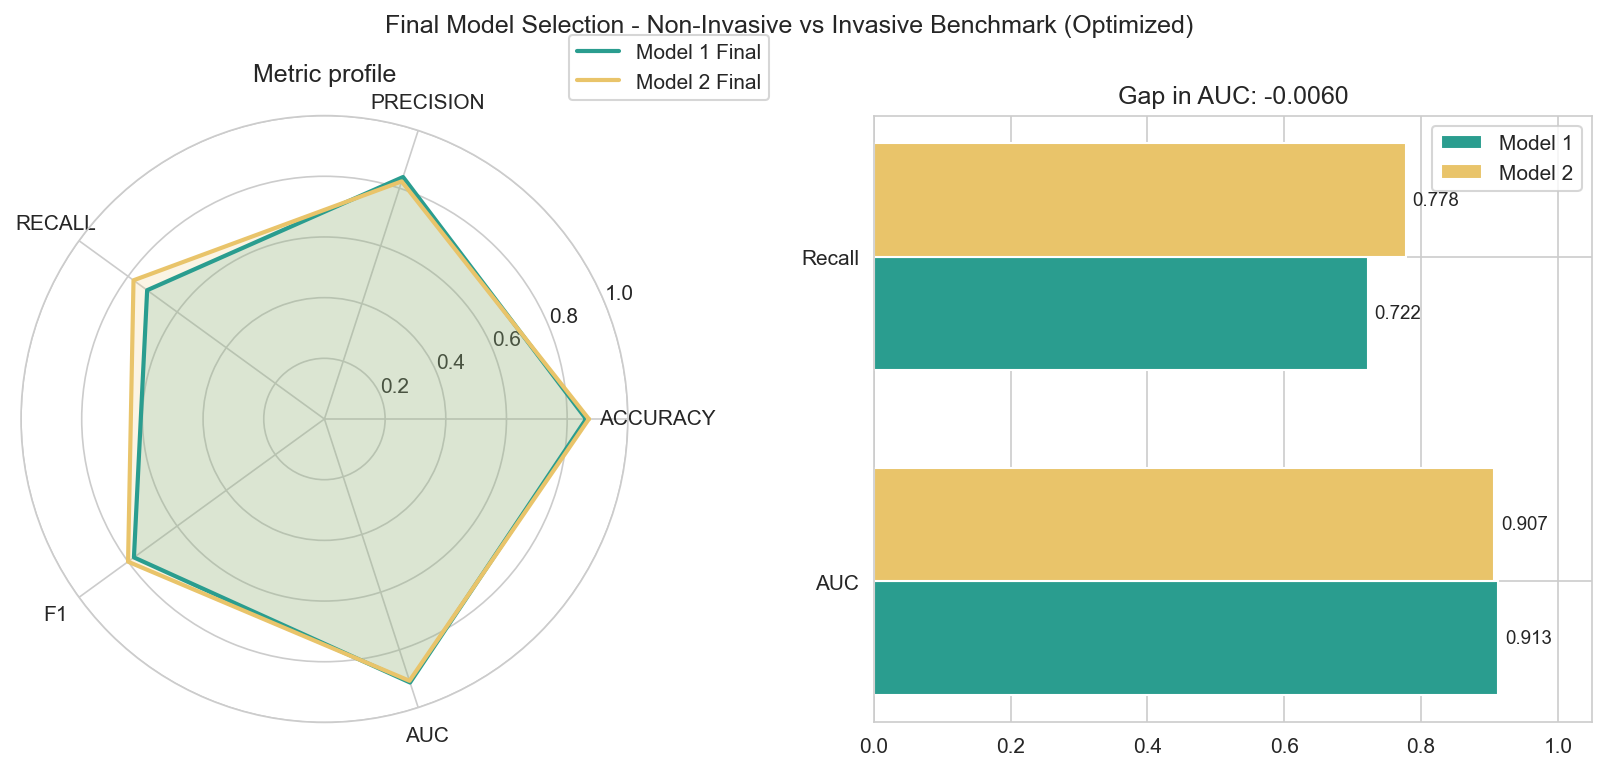

In [63]:
# Plotting the final model selection summary is comparing the two optimized thesis models on the main performance metrics.
categories = ['accuracy', 'precision', 'recall', 'f1', 'auc']
values_m1 = [best_model1_final_row[c] for c in categories]
values_m2 = [best_model2_final_row[c] for c in categories]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values_m1_closed = values_m1 + values_m1[:1]
values_m2_closed = values_m2 + values_m2[:1]
angles_closed = angles + angles[:1]

fig = plt.figure(figsize=(11.0, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1])

ax1 = fig.add_subplot(gs[0, 0], polar=True)
ax1.plot(angles_closed, values_m1_closed, color=COLORS['model1'], lw=2, label='Model 1 Final')
ax1.fill(angles_closed, values_m1_closed, color=COLORS['model1'], alpha=0.18)
ax1.plot(angles_closed, values_m2_closed, color=COLORS['model2'], lw=2, label='Model 2 Final')
ax1.fill(angles_closed, values_m2_closed, color=COLORS['model2'], alpha=0.18)
ax1.set_xticks(angles)
ax1.set_xticklabels([c.upper() for c in categories])
ax1.set_ylim(0, 1.0)
ax1.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))
ax1.set_title('Metric profile')

ax2 = fig.add_subplot(gs[0, 1])
compare_df = pd.DataFrame({
    'Metric': ['AUC', 'Recall'],
    'Model 1': [best_model1_final_row['auc'], best_model1_final_row['recall']],
    'Model 2': [best_model2_final_row['auc'], best_model2_final_row['recall']]
})
y = np.arange(len(compare_df))
height = 0.35
ax2.barh(y - height / 2, compare_df['Model 1'], height=height, color=COLORS['model1'], label='Model 1')
ax2.barh(y + height / 2, compare_df['Model 2'], height=height, color=COLORS['model2'], label='Model 2')
for idx, row in compare_df.iterrows():
    ax2.text(row['Model 1'] + 0.01, idx - height / 2, f"{row['Model 1']:.3f}", va='center', fontsize=9)
    ax2.text(row['Model 2'] + 0.01, idx + height / 2, f"{row['Model 2']:.3f}", va='center', fontsize=9)
ax2.set_yticks(y)
ax2.set_yticklabels(compare_df['Metric'])
ax2.set_xlim(0, 1.05)
ax2.set_title(f'Gap in AUC: {final_gap_auc:.4f}')
ax2.legend()

fig.suptitle('Final Model Selection - Non-Invasive vs Invasive Benchmark (Optimized)')
plt.tight_layout()
plt.savefig('images/optimization/18_final_model_selection_summary.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Final Model Selection Figure
This figure is showing the two final optimized thesis models side by side. The radar view gives the overall shape of performance, while the bar chart makes the AUC and recall gap easier to see directly. This matters because these are the two models that will move forward to SHAP explanation.


In [64]:
# Printing the full final results table is showing the exact values behind the last heatmap of the notebook.
print(final_results.to_string(index=False))


                  model  accuracy  precision  recall     f1    auc model_set algorithm   approach optimizer
           Model 1 - LR    0.8349     0.7368  0.7778 0.7568 0.8839   Model 1        LR Individual       NaN
           Model 1 - RF    0.8532     0.8125  0.7222 0.7647 0.9098   Model 1        RF Individual       NaN
          Model 1 - XGB    0.8716     0.8438  0.7500 0.7941 0.9026   Model 1       XGB Individual       NaN
           Model 2 - LR    0.8349     0.7143  0.8333 0.7692 0.8988   Model 2        LR Individual       NaN
           Model 2 - RF    0.8349     0.7500  0.7500 0.7500 0.8955   Model 2        RF Individual       NaN
          Model 2 - XGB    0.8624     0.8000  0.7778 0.7887 0.9037   Model 2       XGB Individual       NaN
     Model 1 - Stack-LR    0.8440     0.7879  0.7222 0.7536 0.9113   Model 1  Stack-LR   Stacking       NaN
     Model 1 - Stack-RF    0.8440     0.8276  0.6667 0.7385 0.8777   Model 1  Stack-RF   Stacking       NaN
    Model 1 - Stack-XGB    0

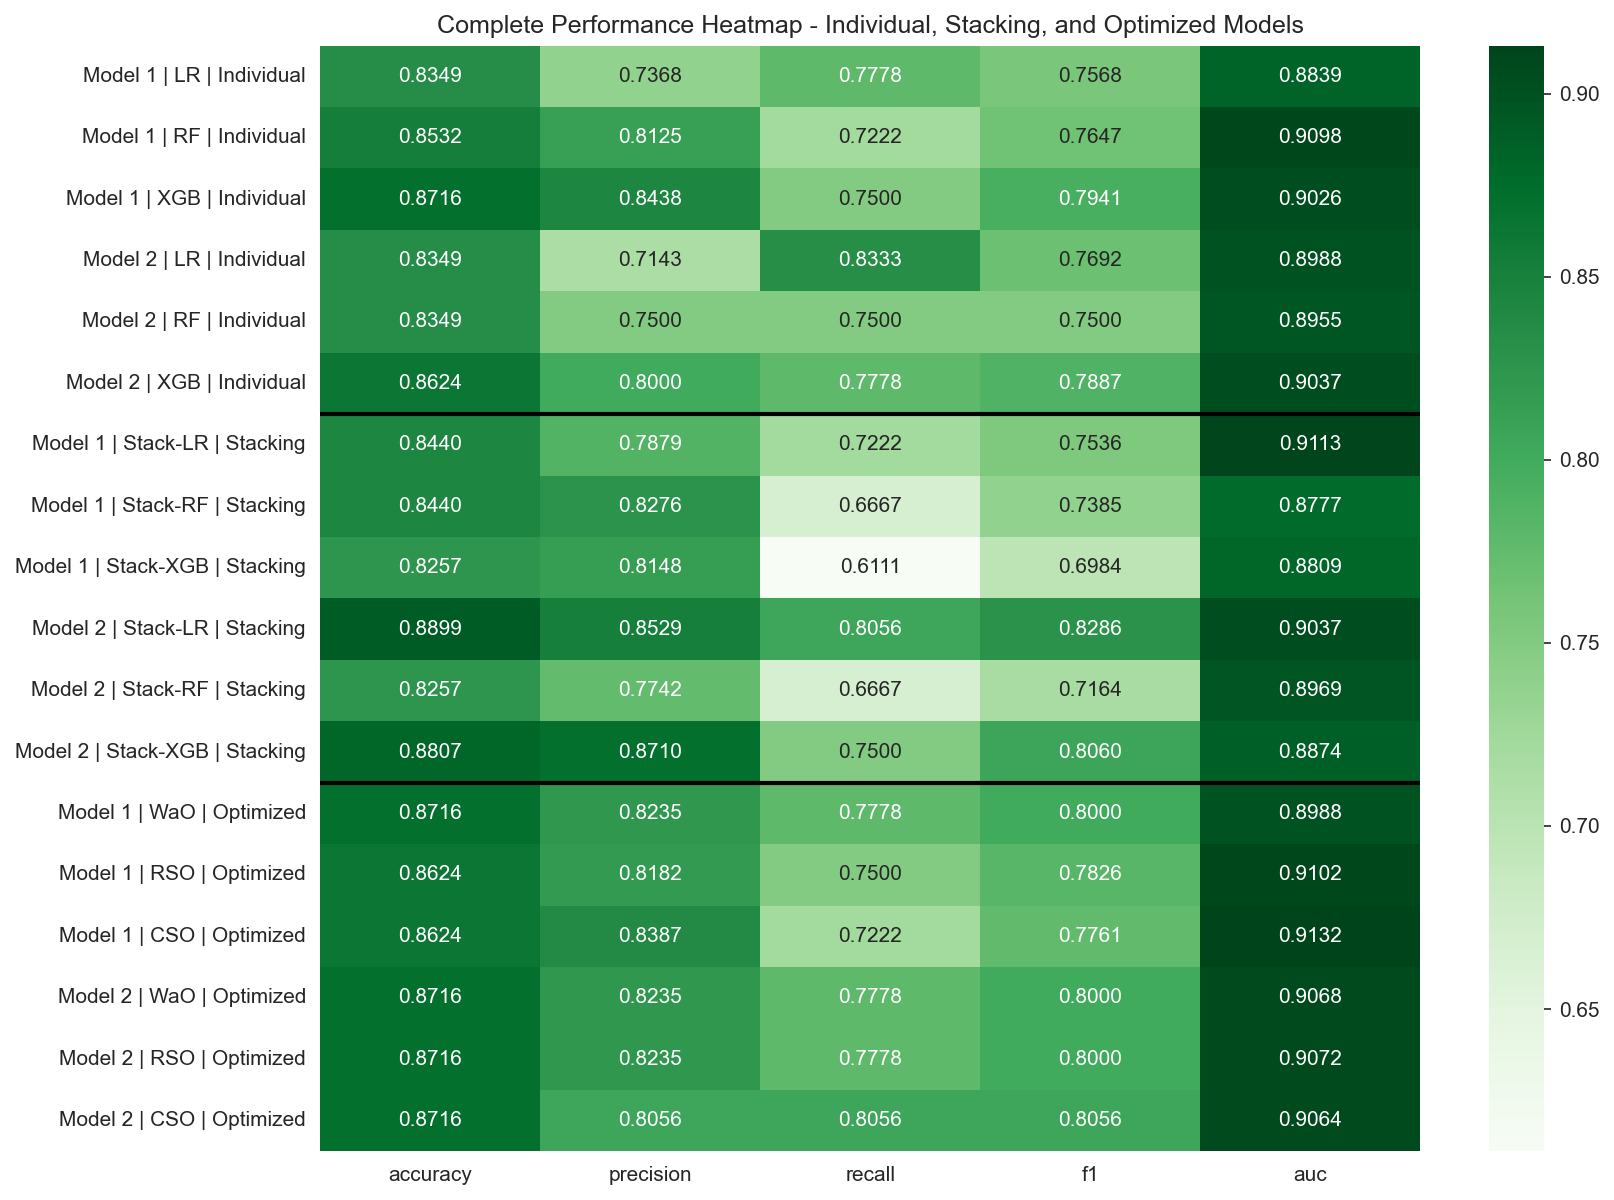

In [67]:
# Plotting the full optimization heatmap is showing the whole performance picture across individual, stacking, and optimized models.
heatmap_df = final_results.copy()
row_labels = []
for _, row in heatmap_df.iterrows():
    if row['approach'] == 'Individual':
        row_labels.append(f"{row['model_set']} | {row['algorithm']} | Individual")
    elif row['approach'] == 'Stacking':
        row_labels.append(f"{row['model_set']} | {row['algorithm']} | Stacking")
    else:
        row_labels.append(f"{row['model_set']} | {row['optimizer']} | Optimized")
metric_heat = heatmap_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].copy()
metric_heat.index = row_labels

fig, ax = plt.subplots(figsize=(11.5, max(6.2, len(metric_heat) * 0.45)))
sns.heatmap(metric_heat, annot=True, fmt='.4f', cmap='Greens', cbar=True, ax=ax)
phase_counts = final_results['approach'].value_counts()
divider_1 = int((final_results['approach'] == 'Individual').sum())
divider_2 = divider_1 + int((final_results['approach'] == 'Stacking').sum())
ax.hlines([divider_1, divider_2], *ax.get_xlim(), colors='black', linewidth=2)
ax.set_title('Complete Performance Heatmap - Individual, Stacking, and Optimized Models')
plt.tight_layout()
plt.savefig('images/optimization/19_master_optimization_heatmap.png', bbox_inches='tight')
plt.show()


### Simple Reading of the Full Heatmap
This heatmap is showing the full modelling journey in one place. It lets us compare the single models, the stacked models, and the optimized models across all main metrics. This matters because it makes the final thesis choice transparent.


### Optimization Findings and Algorithm Comparison
WaO, RSO, and CSO are all searching the same hyperparameter space, but they are doing it in different ways. The final tables and convergence curves are showing whether those different search rules lead to better or worse AUC and recall.

For Model 1, the best optimizer is the one that ends with the highest AUC while still keeping recall strong enough for screening. This result matters because Model 1 is the practical non-invasive model that could be used without laboratory tests.

For Model 2, the best optimizer is the one that gets the most from the invasive benchmark features. This matters because Model 2 is the upper reference for what the non-invasive model is trying to approach.

The progression charts are showing whether optimization adds a real gain after stacking. If the gain is small, it means the stack was already strong. If the gain is clear, it means the optimizer found better hyperparameter settings than the default stack.

The final AUC gap between the optimized Model 1 and optimized Model 2 is the most important summary from this notebook. If that gap stays small, then the non-invasive model is getting close to the invasive benchmark, which supports the main thesis goal.


In [66]:
# Verifying all required optimization outputs is checking that every saved model, table, and figure exists and is non-empty.
required_files = [
    'models/model1_wao_optimized.pkl',
    'models/model1_rso_optimized.pkl',
    'models/model1_cso_optimized.pkl',
    'models/model2_wao_optimized.pkl',
    'models/model2_rso_optimized.pkl',
    'models/model2_cso_optimized.pkl',
    'models/model1_final_optimized.pkl',
    'models/model2_final_optimized.pkl',
    'models/model1_best_params.json',
    'models/model2_best_params.json',
    'models/model1_wao_convergence.npy',
    'models/model1_rso_convergence.npy',
    'models/model1_cso_convergence.npy',
    'models/model2_wao_convergence.npy',
    'models/model2_rso_convergence.npy',
    'models/model2_cso_convergence.npy',
    'cleaned_data/modelling_sets/optimization_results.csv',
    'cleaned_data/modelling_sets/final_model_results.csv',
    'images/optimization/01_what_is_optimization_diagram.png',
    'images/optimization/02_search_space_illustration.png',
    'images/optimization/03_wao_behaviour_illustration.png',
    'images/optimization/04_rso_behaviour_illustration.png',
    'images/optimization/05_cso_behaviour_illustration.png',
    'images/optimization/06_model1_wao_convergence.png',
    'images/optimization/07_model1_rso_convergence.png',
    'images/optimization/08_model1_cso_convergence.png',
    'images/optimization/09_model1_all_convergence_comparison.png',
    'images/optimization/10_model2_wao_convergence.png',
    'images/optimization/11_model2_rso_convergence.png',
    'images/optimization/12_model2_cso_convergence.png',
    'images/optimization/13_model2_all_convergence_comparison.png',
    'images/optimization/14_model1_optimizer_performance_comparison.png',
    'images/optimization/15_model2_optimizer_performance_comparison.png',
    'images/optimization/16_model1_optimized_vs_baseline_comparison.png',
    'images/optimization/17_model2_optimized_vs_baseline_comparison.png',
    'images/optimization/18_final_model_selection_summary.png',
    'images/optimization/19_master_optimization_heatmap.png',
]
all_passed = True
for path in required_files:
    exists = os.path.exists(path)
    non_empty = exists and os.path.getsize(path) > 0
    status = 'PASS' if non_empty else 'FAIL'
    if not non_empty:
        all_passed = False
    print(f'[{status}] {path}')
print()
if all_passed:
    print('All optimization outputs verified successfully.')
else:
    print('WARNING: Some optimization outputs are missing or empty.')


[PASS] models/model1_wao_optimized.pkl
[PASS] models/model1_rso_optimized.pkl
[PASS] models/model1_cso_optimized.pkl
[PASS] models/model2_wao_optimized.pkl
[PASS] models/model2_rso_optimized.pkl
[PASS] models/model2_cso_optimized.pkl
[PASS] models/model1_final_optimized.pkl
[PASS] models/model2_final_optimized.pkl
[PASS] models/model1_best_params.json
[PASS] models/model2_best_params.json
[PASS] models/model1_wao_convergence.npy
[PASS] models/model1_rso_convergence.npy
[PASS] models/model1_cso_convergence.npy
[PASS] models/model2_wao_convergence.npy
[PASS] models/model2_rso_convergence.npy
[PASS] models/model2_cso_convergence.npy
[PASS] cleaned_data/modelling_sets/optimization_results.csv
[PASS] cleaned_data/modelling_sets/final_model_results.csv
[PASS] images/optimization/01_what_is_optimization_diagram.png
[PASS] images/optimization/02_search_space_illustration.png
[PASS] images/optimization/03_wao_behaviour_illustration.png
[PASS] images/optimization/04_rso_behaviour_illustration.pn

### Notebook Summary and Next Steps
This notebook is completing the optimization phase of the thesis. It is testing WaO, RSO, and CSO on both model sets, saving every optimizer result, and selecting one final optimized model for Model 1 and one final optimized model for Model 2.

The two saved thesis models are `model1_final_optimized.pkl` and `model2_final_optimized.pkl`. These are the models that will move into the next notebook.

Notebook 11 is applying SHAP to both final optimized models. That next step is turning these optimized ensemble models into explainable models by showing which features matter most overall and which features are driving individual PCOS predictions.
